# BOAMP Renewal Linking — EDA & Preprocessing

**Objective**: Build a clean, transparent, and reproducible workflow to construct renewal links between BOAMP `APPEL_OFFRE` notices and their later renewals.

BOAMP provides no explicit renewal link. We reconstruct it from four signals:
- **Buyer identity** — SIRET when available, normalized name otherwise
- **CPV category** — 4-level compatibility score (exact / 4-digit / 2-digit / section)
- **Textual similarity** — TF-IDF cosine on the `objet` field
- **Temporal proximity** — publication date of candidate falls near expected renewal date

**Main improvement over the existing baseline** (`task_boamp_full_survival.py`, 7.6% linking rate at the current W=6 window; 11.3% at the earlier W=12 setting): the previous script required *both* same buyer AND same `cpv_div2` in the groupby, making any CPV drift fatal. Here, CPV is a scored component only.

**Target**: 40–60% linking rate over the *eligible* denominator (defined in Section 1.6).

---
**Dataset**: `data/processed/boamp_full_clean.csv` — 3 181 notices, Pays de la Loire, digital CPV, 2015–2024.  
**No DECP data is used in this notebook.**

---
## 0. Setup

In [1]:
# Install dependencies (add to requirements.txt for reproducibility)
import importlib, subprocess, sys

for pkg, spec in [("scikit-learn", "sklearn"), ("sentence-transformers", "sentence_transformers")]:
    if importlib.util.find_spec(spec) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        print(f"{pkg} installed")
    else:
        mod = importlib.import_module(spec)
        print(f"{pkg} {getattr(mod, '__version__', 'ok')} already available")

scikit-learn 1.9.0 already available


sentence-transformers 5.5.1 already available


In [2]:
import re
import unicodedata
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Project paths (notebook lives inside boamp_renewal_linking_quality/)
NOTEBOOK_DIR = Path(".").resolve()
ROOT         = NOTEBOOK_DIR.parent
PROCESSED    = ROOT / "data" / "processed"
SCRIPTS      = ROOT / "scripts"
OUTPUTS      = NOTEBOOK_DIR / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

# Import shared cleaning utilities from the main pipeline
sys.path.insert(0, str(SCRIPTS))
from task7_week2_cleaning import normalize_name, canonical_buyer_key, clean_cpv

pd.set_option("display.max_colwidth", 90)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Paths:")
print(f"  ROOT:      {ROOT}")
print(f"  PROCESSED: {PROCESSED}")
print(f"  OUTPUTS:   {OUTPUTS}")


Paths:
  ROOT:      /home/senghakrou/stage-1
  PROCESSED: /home/senghakrou/stage-1/data/processed
  OUTPUTS:   /home/senghakrou/stage-1/boamp_renewal_linking_quality/outputs


In [3]:
# ── Academic figure style (consistent across all project notebooks) ────────
try:
    plt.style.use("seaborn-v0_8-paper")
except OSError:
    try:
        plt.style.use("seaborn-paper")
    except OSError:
        pass

plt.rcParams.update({
    "font.family":          "serif",
    "font.size":            11,
    "axes.titlesize":       13,
    "axes.labelsize":       12,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "axes.grid":            True,
    "grid.alpha":           0.25,
    "grid.linestyle":       "--",
    "grid.linewidth":       0.6,
    "legend.frameon":       True,
    "legend.framealpha":    0.85,
    "legend.edgecolor":     "0.8",
    "lines.linewidth":      1.8,
    "figure.dpi":           120,
    "savefig.dpi":          300,
    "savefig.bbox":         "tight",
    "xtick.direction":      "out",
    "ytick.direction":      "out",
    "xtick.minor.visible":  True,
    "ytick.minor.visible":  True,
})
print("Academic figure style configured.")


Academic figure style configured.


In [4]:
# ── Algorithm constants ────────────────────────────────────────────────────────
DEFAULT_DURATION_MONTHS = 48.0   # assumed when duration_clean is missing
TEMPORAL_WINDOW_MONTHS  = 6.0    # ±6 months around estimated end date
#   Rationale: calibration (Section 2.6) shows 96% of same-contract pairs score ≥ 0.30;
#   Reduced to 6m for tighter precision; aligns with DECP linking (task6_renewal_linking.py).
MIN_TEXT_SIMILARITY     = 0.20   # TF-IDF cosine threshold
#   Rationale: calibration shows 96% of guaranteed same-contract pairs score ≥ 0.30,
#   so 0.20 is conservative enough to catch rewrites while rejecting unrelated notices.
MIN_GAP_MONTHS          = 6.0    # minimum time between original and renewal
MAX_GAP_MONTHS          = 72.0   # maximum gap (6 years) to cover long-duration contracts
STUDY_START             = pd.Timestamp("2015-01-01")
STUDY_END               = pd.Timestamp("2024-12-31")
GENERIC_CPV_CODES       = {"48000000", "72000000", "32000000", "35000000"}

# Composite score weights (must sum to 1.0)
W_TEXT     = 0.40
W_CPV      = 0.25
W_TEMPORAL = 0.20
W_BUYER    = 0.15
assert abs(W_TEXT + W_CPV + W_TEMPORAL + W_BUYER - 1.0) < 1e-9

### Load data

In [5]:
df = pd.read_csv(
    PROCESSED / "boamp_full_clean_siren_enriched.csv",
    low_memory=False,
    dtype={"buyer_siret": str, "cpv_clean": str, "cpv_div2": str, "cpv_class4": str,
           "enriched_siren": str, "enriched_siret": str},
)

# Use SIREN-enriched buyer key as the active grouping key.
# buyer_key_enriched = SIREN:{9-digit} for HIGH-confidence matches;
# otherwise falls back to the original NAME: / SIRET: key.
# This expands the candidate pool for 23 buyer aliases merged by SIREN.
df["buyer_key"] = df["buyer_key_enriched"]

# Parse date columns
for col in ["dateparution", "date_attribution", "date_publication_anterieure", "datelimitereponse"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Loaded {len(df):,} records, {df.shape[1]} columns")
print(f"Active buyer_key: {df['buyer_key'].nunique():,} unique keys "      f"({df['buyer_key'].str.startswith('SIREN:').sum():,} SIREN-enriched)")
print(f"\nColumns ({df.shape[1]}):")
print(list(df.columns))


Loaded 3,181 records, 57 columns
Active buyer_key: 462 unique keys (1,919 SIREN-enriched)

Columns (57):
['idweb', 'dateparution', 'datefindiffusion', 'datelimitereponse', 'nomacheteur', 'code_departement', 'famille', 'nature', 'nature_libelle', 'type_procedure', 'type_marche', 'type_avis', 'descripteur_libelle', 'objet', 'titulaire', 'annonce_lie', 'contractfolderid', 'etat', 'url_avis', 'donnees_format', 'cpv_principal', 'cpv_all', 'buyer_siret', 'buyer_cp', 'buyer_ville', 'amount_eur', 'duration_months', 'duration_source_field', 'date_attribution', 'date_publication_anterieure', 'buyer_key_original', 'cpv_clean', 'cpv_full8', 'cpv_div2', 'cpv_group3', 'cpv_class4', 'cpv_category5', 'cpv_is_missing', 'cpv_is_generic', 'amount_raw', 'flag_amount_zero', 'flag_amount_tiny', 'flag_amount_ceiling', 'amount_clean', 'duration_raw_boamp', 'flag_duration_suspect', 'duration_clean', 'category_id', 'category_label', 'buyer_key_enriched', 'enriched_siren', 'enriched_siret', 'enrichment_confidenc

### Raw dataset preview
Before any filtering or feature engineering — all 3,181 records across all notice types.

In [6]:
# Raw dataset — first look
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData types:")
print(df.dtypes.to_string())
print(f"\nMissing values (top 10 columns):")
print(df.isnull().sum().sort_values(ascending=False).head(10).to_string())
df.head(10)

Shape: 3,181 rows × 57 columns

Data types:
idweb                                       object
dateparution                        datetime64[ns]
datefindiffusion                            object
datelimitereponse              datetime64[ns, UTC]
nomacheteur                                 object
code_departement                            object
famille                                     object
nature                                      object
nature_libelle                              object
type_procedure                              object
type_marche                                 object
type_avis                                   object
descripteur_libelle                         object
objet                                       object
titulaire                                   object
annonce_lie                                 object
contractfolderid                            object
etat                                        object
url_avis                              

,idweb,dateparution,datefindiffusion,datelimitereponse,nomacheteur,code_departement,famille,nature,nature_libelle,type_procedure,...,category_id,category_label,buyer_key_enriched,enriched_siren,enriched_siret,enrichment_confidence,enrichment_score,enrichment_source,enrichment_status,buyer_key
0,15-30947,2015-03-02,2015-03-27,2015-03-27 11:30:00+00:00,SMICTOM de la Vallée de l'Authion,49,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,CAT01,Software & Applications,NAME:smictom de la vallee de l authion,NaN,NaN,NO_MATCH,NaN,api_recherche_entreprises,no_match,NAME:smictom de la vallee de l authion
1,15-31464,2015-03-02,2015-04-24,2015-04-24 15:00:00+00:00,Sdis de la Mayenne,53,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,CAT_UNKNOWN,Unknown,SIREN:285300018,285300018,28530001800030,HIGH,100.0,api_recherche_entreprises,matched,SIREN:285300018
2,15-31513,2015-03-02,2015-04-17,2015-04-17 11:00:00+00:00,Ville de Rezé,44,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,CAT_UNKNOWN,Unknown,SIREN:214401432,214401432,21440143200015,HIGH,100.0,api_recherche_entreprises,matched,SIREN:214401432
3,15-20937,2015-03-03,2015-04-14,2015-04-14 11:00:00+00:00,Ville de Nantes,44,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,CAT_UNKNOWN,Unknown,SIREN:214401093,214401093,21440109300015,HIGH,100.0,api_recherche_entreprises,matched,SIREN:214401093
4,15-31397,2015-03-03,2015-04-01,NaT,SDIS de la Sarthe,72,JOUE,ATTRIBUTION,Résultat de marché,NEGOCIE,...,CAT01,Software & Applications,SIREN:287200265,287200265,28720026500018,HIGH,100.0,api_recherche_entreprises,matched,SIREN:287200265
5,15-32168,2015-03-03,2015-04-13,2015-04-13 12:00:00+00:00,Conseil régional des Pays de la Loire,44,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,CAT02,IT Services & Consulting,SIREN:234400034,234400034,23440003400026,HIGH,81.3,api_recherche_entreprises,matched,SIREN:234400034
6,15-31641,2015-03-04,2015-04-17,2015-04-17 11:00:00+00:00,IRCANTEC,49|44|75,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,CAT08,Data & AI,SIREN:784301525,784301525,78430152500050,HIGH,100.0,api_recherche_entreprises,matched,SIREN:784301525
7,15-31797,2015-03-04,2015-04-14,2015-04-14 15:00:00+00:00,ACOSS,93|44,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,CAT02,IT Services & Consulting,NAME:acoss,NaN,NaN,NO_MATCH,26.5,api_recherche_entreprises,no_match,NAME:acoss
8,15-32296,2015-03-04,2015-06-03,NaT,CHU de Nantes,44,JOUE,ATTRIBUTION,Résultat de marché,OUVERT,...,CAT01,Software & Applications,SIREN:264400136,264400136,26440013600471,HIGH,91.3,api_recherche_entreprises,matched,SIREN:264400136
9,15-32693,2015-03-04,2015-04-02,NaT,Ville de Bouguenais,44,JOUE,ATTRIBUTION,Résultat de marché,OUVERT,...,CAT05,Cloud & Infrastructure,SIREN:214400202,214400202,21440020200013,HIGH,100.0,api_recherche_entreprises,matched,SIREN:214400202


In [7]:
# Notice-type breakdown
print("nature distribution:")
print(df["nature"].value_counts())

# Working subsets
ao   = df[df["nature"] == "APPEL_OFFRE"].copy().reset_index(drop=True)
attr = df[df["nature"] == "ATTRIBUTION"].copy().reset_index(drop=True)

print(f"\nAPPEL_OFFRE (survival units): {len(ao):,}")
print(f"ATTRIBUTION (award notices):  {len(attr):,}")

nature distribution:
nature
APPEL_OFFRE           1933
ATTRIBUTION           1081
RECTIFICATIF           150
PRE-INFORMATION          7
MODIFICATION             5
INTENTION_CONCLURE       4
PERIODIQUE               1
Name: count, dtype: int64

APPEL_OFFRE (survival units): 1,933
ATTRIBUTION (award notices):  1,081


---
## 1. BOAMP Data Quality Diagnosis

We diagnose nine data quality issues that directly affect the renewal linking algorithm. Each issue is quantified and its impact on matching is explained.

### 1.1 Buyer identifier coverage

SIRET (14-digit company ID) is the ideal buyer key because it is unambiguous. However, BOAMP only started collecting SIRET in 2024 (eForms format). For 90%+ of notices, buyer identification relies on a normalized version of the free-text `nomacheteur` field.

**Impact on linking**: Name-based keys may split one buyer into multiple groups (e.g. "Conseil Départemental 44" vs "CD44" vs "Département de Loire-Atlantique"), creating structural misses.

In [8]:
siren_n  = ao["buyer_key"].str.startswith("SIREN:").sum()
siret_n  = ao["buyer_key"].str.startswith("SIRET:").sum()
name_n   = ao["buyer_key"].str.startswith("NAME:").sum()
unk_n    = (~ao["buyer_key"].str.startswith(("SIREN:", "SIRET:", "NAME:"))).sum()

print(f"SIREN-enriched buyer keys: {siren_n:,}  ({100*siren_n/len(ao):.1f}%)")
print(f"SIRET-anchored buyer keys: {siret_n:,}  ({100*siret_n/len(ao):.1f}%)")
print(f"Name-anchored buyer keys:  {name_n:,}  ({100*name_n/len(ao):.1f}%)")
print(f"Unknown / missing keys:    {unk_n:,}")
print()

print(f"Raw unique nomacheteur:   {ao['nomacheteur'].nunique():,}")
print(f"Canonical buyer_key:      {ao['buyer_key'].nunique():,}")
print(f"(SIREN enrichment reduced unique keys by "
      f"{ao['buyer_key_original'].nunique() - ao['buyer_key'].nunique()} via alias merging)")


SIREN-enriched buyer keys: 1,131  (58.5%)
SIRET-anchored buyer keys: 43  (2.2%)
Name-anchored buyer keys:  759  (39.3%)
Unknown / missing keys:    0

Raw unique nomacheteur:   500
Canonical buyer_key:      444
(SIREN enrichment reduced unique keys by 31 via alias merging)


In [9]:
buyer_counts = ao["buyer_key"].value_counts()
multi_buyers = buyer_counts[buyer_counts >= 2]
print(f"Buyers with ≥2 AO notices:  {len(multi_buyers):,}")
print(f"AO in multi-notice buyers:  {multi_buyers.sum():,}  ({100*multi_buyers.sum()/len(ao):.1f}% of AO)")
print(f"Solo buyers (1 AO only):    {(buyer_counts == 1).sum():,}  — structurally unlinked by definition")
print()
print("Top 15 buyers by AO count:")
buyer_counts.head(15).rename("ao_count").to_frame()

Buyers with ≥2 AO notices:  226
AO in multi-notice buyers:  1,715  (88.7% of AO)
Solo buyers (1 AO only):    218  — structurally unlinked by definition

Top 15 buyers by AO count:


,ao_count
buyer_key,
NAME:nantes metropole,134
SIREN:234400034,116
SIREN:264400136,66
SIREN:214401846,50
SIREN:244900015,46
SIREN:391722881,46
SIREN:935367433,38
SIREN:194909701,38
SIREN:227200029,36


### 1.2 Missing or inconsistent buyer names

The `normalize_name()` function in `task7_week2_cleaning.py` removes accents, legal suffixes ("Ville de", "SARL", etc.), and punctuation. Below we show examples where buyer name normalization may still fail to unify the same entity.

In [10]:
# Show buyer keys that appear with slight variants in the raw name
ao["nomacheteur_norm"] = ao["nomacheteur"].map(normalize_name)
name_variants = (
    ao.groupby("buyer_key")["nomacheteur"]
    .agg(lambda x: list(x.unique()))
    .reset_index()
)
name_variants["n_variants"] = name_variants["nomacheteur"].map(len)

print(f"Buyer keys with >1 raw name variant: {(name_variants['n_variants'] > 1).sum()}")
print()
print("Example buyer keys with multiple raw name variants (showing top 5):")
name_variants[name_variants["n_variants"] > 1].nlargest(5, "n_variants")[["buyer_key", "n_variants", "nomacheteur"]]

Buyer keys with >1 raw name variant: 43

Example buyer keys with multiple raw name variants (showing top 5):


,buyer_key,n_variants,nomacheteur
328,SIREN:234400034,5,"[Conseil régional des Pays de la Loire, préfet de la région Pays de la Loire, REGION P..."
284,SIREN:214400558,4,"[VILLE DE LA BAULE-ESCOUBLAC, Commune de La Baule, Mairie de La Baule-Escoublac, Ville..."
209,SIREN:130001704,3,"[DIR INTERDEPARTEMENTALE ROUTES OUEST, DIR INTERDEPARTEMENTALE DES RTE OUEST, Directio..."
217,SIREN:130029747,3,"[Université de Nantes, Nantes Université, NANTES UNIVERSITE]"
293,SIREN:214401432,3,"[Ville de Rezé, COMMUNE DE REZE, MAIRIE DE REZE]"


### 1.3 Missing or generic CPV codes

CPV codes classify the product or service. Generic codes (e.g. `72000000` — IT services in general) provide no discriminating power at the 8-digit level. We track two types of quality issues:
- **Missing** CPV: field is blank
- **Generic** CPV: 8-digit code ending in `000000` (division-level catch-all)

AO with missing CPV:  62 (3.2%)
AO with generic CPV:  0 (0.0%)



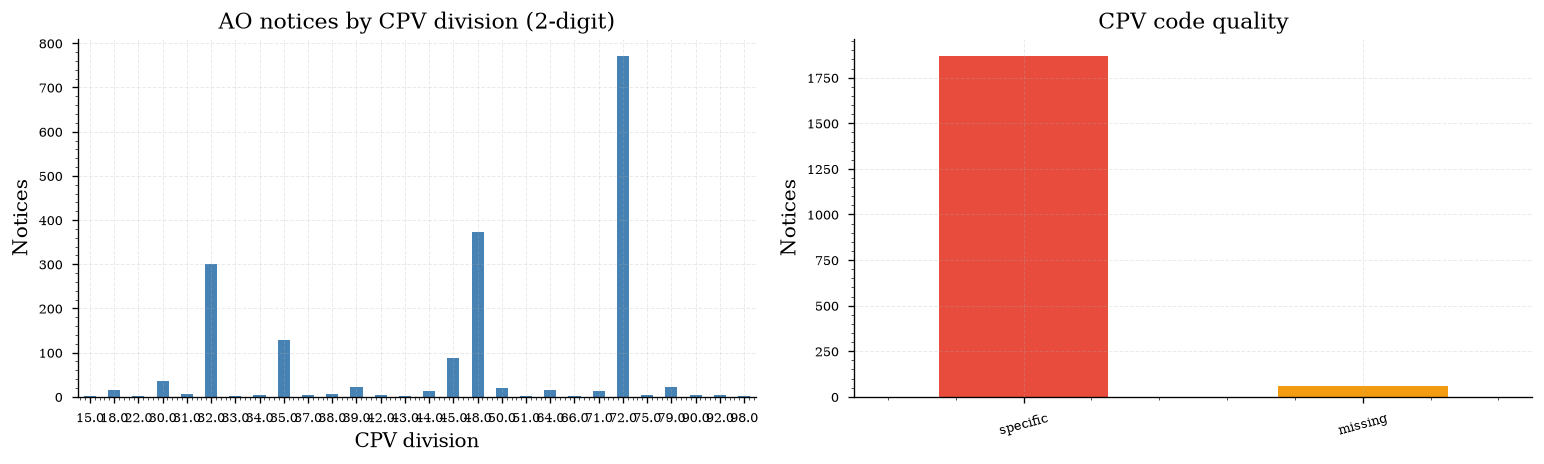

In [11]:
ao["cpv_missing"] = ao["cpv_clean"].isna()
ao["cpv_is_generic"] = ao["cpv_clean"].fillna("").str.endswith("000000")

print(f"AO with missing CPV:  {ao['cpv_missing'].sum():,} ({100*ao['cpv_missing'].mean():.1f}%)")
print(f"AO with generic CPV:  {ao['cpv_is_generic'].sum():,} ({100*ao['cpv_is_generic'].mean():.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CPV division distribution
cpv_div_counts = ao["cpv_div2"].value_counts().sort_index()
cpv_div_counts.plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="AO notices by CPV division (2-digit)",
            xlabel="CPV division", ylabel="Notices")
axes[0].tick_params(axis="x", rotation=0)

# Generic vs specific CPV
ao["cpv_quality"] = np.where(ao["cpv_missing"], "missing",
                    np.where(ao["cpv_is_generic"], "generic (division level)", "specific"))
ao["cpv_quality"].value_counts().plot.bar(ax=axes[1], color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[1].set(title="CPV code quality", xlabel="", ylabel="Notices")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 1.4 Aberrant contract amounts

The cleaning pipeline (`task_boamp_full_clean.py`) already flagged three types of aberrant amounts:
- `flag_amount_zero`: amount = 0 EUR (encoding artefact)
- `flag_amount_tiny`: 0 < amount < 1 000 EUR (unrealistically small)
- `flag_amount_ceiling`: amount ≥ 10 000 000 EUR (likely a framework-agreement ceiling, not a real contract value)

Flagged values are set to NaN in `amount_clean`. No data is deleted.

flag_amount_zero: 0 (0.0%)
flag_amount_tiny: 5 (0.3%)
flag_amount_ceiling: 15 (0.8%)

amount_clean filled: 413 / 1,933 (21.4%)


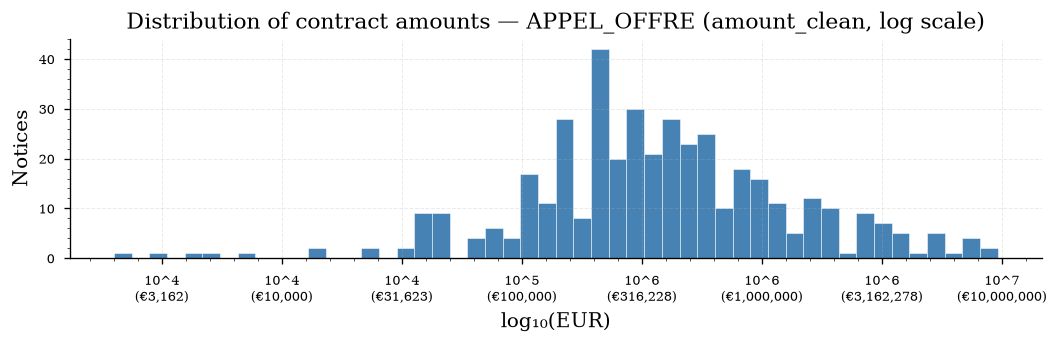

In [12]:
flags = ["flag_amount_zero", "flag_amount_tiny", "flag_amount_ceiling"]
flag_counts = {f: ao[f].fillna(0).astype(bool).sum() for f in flags}
for f, n in flag_counts.items():
    print(f"{f}: {n:,} ({100*n/len(ao):.1f}%)")
print()
print(f"amount_clean filled: {ao['amount_clean'].notna().sum():,} / {len(ao):,} "
      f"({100*ao['amount_clean'].notna().mean():.1f}%)")

amt = ao["amount_clean"].dropna()
amt_log = np.log10(amt[amt > 0])

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(amt_log, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set(xlabel="log₁₀(EUR)", ylabel="Notices",
       title="Distribution of contract amounts — APPEL_OFFRE (amount_clean, log scale)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"10^{x:.0f}\n(€{10**x:,.0f})"))
plt.tight_layout()
plt.show()

### 1.5 Missing or coarse contract durations

Duration is the most critical field for the renewal linking algorithm: it defines the temporal window around which we search for a renewal. Two problems:
- **Missing duration** (52% of AO): we default to 48 months
- **Whole-year rounding** (most declared durations are exactly 12/24/36/48 months): indicates the duration is the administrative maximum, not the expected contract lifetime

**Assumption**: declared duration ≈ maximum administrative duration (base period + all renewals). The actual first renewal may occur earlier.

duration_clean filled: 1,480 / 1,933 (76.6%)
Missing (will use default 48m): 453

Filled durations — summary statistics (months):
count    1480.0
mean       30.8
std        21.2
min         1.0
25%        12.0
50%        24.0
75%        48.0
max       120.0
Name: duration_clean, dtype: float64

Exactly a whole-year multiple: 1,140 (77.0%)
Exactly 12/24/36/48m:         1,028 (69.5%)


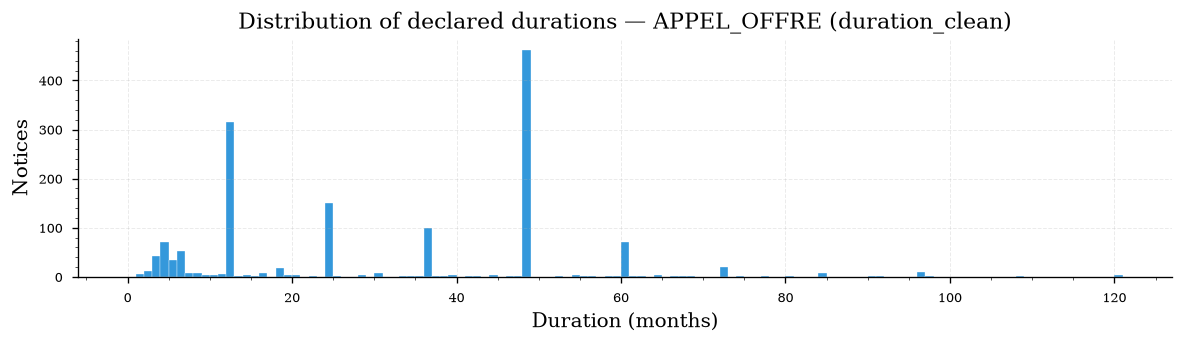

In [13]:
dur = ao["duration_clean"].dropna()
fill_rate = len(dur) / len(ao)
print(f"duration_clean filled: {len(dur):,} / {len(ao):,} ({100*fill_rate:.1f}%)")
print(f"Missing (will use default {DEFAULT_DURATION_MONTHS:.0f}m): {len(ao)-len(dur):,}")
print()
print("Filled durations — summary statistics (months):")
print(dur.describe().round(1))
print()
round_vals = {12, 24, 36, 48, 60, 72, 96}
print(f"Exactly a whole-year multiple: {(dur % 12 == 0).sum():,} ({100*(dur % 12 == 0).mean():.1f}%)")
print(f"Exactly 12/24/36/48m:         {dur.isin({12,24,36,48}).sum():,} ({100*dur.isin({12,24,36,48}).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(10, 3))
dur.hist(bins=range(0, int(dur.max())+2), ax=ax, color="#3498db", edgecolor="white", linewidth=0.2)
ax.set(xlabel="Duration (months)", ylabel="Notices",
       title="Distribution of declared durations — APPEL_OFFRE (duration_clean)")
plt.tight_layout()
plt.show()

### 1.6 Date quality and eligibility definition

This cell defines the **primary denominator** for the linking rate:

> An AO notice is **eligible** for renewal linking if its expected renewal search window  
> (`estimated_end_date ± TEMPORAL_WINDOW_MONTHS`) falls entirely within the study period  
> (2015-01-01 to 2024-12-31).

AO notices whose window extends past 2024-12-31 are **right-censored**: even a perfect algorithm cannot link them because the renewal has not yet occurred (or is not yet published). These must be excluded from the denominator.

In [14]:
# Publication date coverage
ao["pub_date"] = ao["dateparution"]
print(f"pub_date (dateparution) filled: {ao['pub_date'].notna().sum():,} / {len(ao):,}")
print(f"date_attribution filled:        {ao['date_attribution'].notna().sum():,} / {len(ao):,}")

# Duration to use (declared or default)
ao["dur_used"] = ao["duration_clean"].clip(1, 120).fillna(DEFAULT_DURATION_MONTHS)
ao["dur_was_imputed"] = ao["duration_clean"].isna()

# Estimated end date (using pub_date as start — refined in Section 2)
ao["estimated_end_date"] = ao["pub_date"] + pd.to_timedelta(ao["dur_used"] * 30.44, unit="D")
ao["renewal_win_open"]   = ao["estimated_end_date"] - pd.to_timedelta(TEMPORAL_WINDOW_MONTHS * 30.44, unit="D")
ao["renewal_win_close"]  = ao["estimated_end_date"] + pd.to_timedelta(TEMPORAL_WINDOW_MONTHS * 30.44, unit="D")

# Eligibility
ao["right_censored"] = ao["renewal_win_close"] > STUDY_END
ao["eligible"]       = ~ao["right_censored"] & ao["pub_date"].notna()

n_total    = len(ao)
n_censored = ao["right_censored"].sum()
n_eligible = ao["eligible"].sum()

print(f"\nTotal APPEL_OFFRE:             {n_total:,}")
print(f"Right-censored (window > Dec 2024): {n_censored:,}")
print(f"ELIGIBLE (primary denominator):     {n_eligible:,}")

print("\nEligible AO by publication year:")
ao.groupby(ao["pub_date"].dt.year)["eligible"].sum().astype(int).rename("eligible_ao").to_frame()

pub_date (dateparution) filled: 1,933 / 1,933
date_attribution filled:        0 / 1,933

Total APPEL_OFFRE:             1,933
Right-censored (window > Dec 2024): 723
ELIGIBLE (primary denominator):     1,210

Eligible AO by publication year:


,eligible_ao
pub_date,
2015,129
2016,174
2017,192
2018,199
2019,180
2020,135
2021,94
2022,68
2023,26


### 1.7 Objet text quality

The `objet` field is the contract description used for semantic text matching (Sentence-Transformers). Poor text quality (missing, very short, or duplicated objects) directly reduces the reliability of the text similarity score.

In [15]:
ao["objet_len"] = ao["objet"].str.len().fillna(0).astype(int)
ao["flag_missing_objet"] = ao["objet"].isna()
ao["flag_short_objet"]   = ao["objet_len"] < 20

print(f"Missing objet:          {ao['flag_missing_objet'].sum():,} ({100*ao['flag_missing_objet'].mean():.1f}%)")
print(f"Very short (<20 chars): {ao['flag_short_objet'].sum():,} ({100*ao['flag_short_objet'].mean():.1f}%)")
print()
print("Objet length — summary statistics (chars):")
print(ao["objet_len"].describe().round(0))

# Exact duplicates
dup_mask = ao["objet"].duplicated(keep=False)
print(f"\nDuplicate objet strings: {dup_mask.sum():,} ({100*dup_mask.mean():.1f}%)")
print()
print("Top 10 most repeated objet strings:")
ao["objet"].value_counts().head(10).to_frame()

Missing objet:          0 (0.0%)
Very short (<20 chars): 24 (1.2%)

Objet length — summary statistics (chars):
count    1933.0
mean      105.0
std        45.0
min         6.0
25%        71.0
50%        98.0
75%       135.0
max       201.0
Name: objet_len, dtype: float64

Duplicate objet strings: 174 (9.0%)

Top 10 most repeated objet strings:


,count
objet,
Matériels de réseau informatique,4
Maintenance des matériels de téléphonie Alcatel,4
"Acquisition de logiciels d'infrastructures techniques ou bureautiques et services associés, pour le Département de Loire-Atlantique, les structures associées et les collèges du Département de Loire-At",3
"Fourniture de logiciels bureautiques, maintenance et prestations associées pour les besoins du SDIS 44.",3
Location et achats ponctuels de matériels pour les festivités et divers évènements et réalisation de prestations associées,3
RENOUVELLEMENT MATERIEL AUDIOVISUEL pour le lycée Leonard de Vinci (85),3
Numérisation des photos pour la personnalisation des cartes Vitale,3
Fournitures de canalisations et accessoires pour réseaux d'eau potable et d'assainissement pour la période - Durée de 4 ans,3
Acquisition et maintenance de matériels audio-vidéo et d'éclairage,3


### 1.8 `annonce_lie` — What it is and how we use it

`annonce_lie` appears on **ATTRIBUTION** (award) notices. It references the original call for tender (`APPEL_OFFRE`) that the award is responding to. This is a **same-contract** back-reference, not a renewal link.

**How we use it**:
1. **Contract start date**: the award date from the linked ATTRIBUTION is more precise than `dateparution`. We use it to shift the temporal window slightly.
2. **TF-IDF calibration**: ATTRIBUTION notices often repeat the original objet text. Comparing their TF-IDF vectors reveals the upper bound of same-contract similarity.

**What we do NOT do**: we do not treat `annonce_lie` as a renewal link.

In [16]:
ao_idweb_set = set(ao["idweb"].astype(str))

# Build award_index: APPEL_OFFRE idweb → award date (from linked ATTRIBUTION)
award_index = {}
for _, row in attr.iterrows():
    ref = str(row.get("annonce_lie", "")).strip()
    if ref and ref in ao_idweb_set and pd.notna(row.get("date_attribution")):
        try:
            award_index[ref] = pd.Timestamp(str(row["date_attribution"]))
        except Exception:
            pass

print(f"ATTRIBUTION notices:                    {len(attr):,}")
print(f"With annonce_lie:                       {attr['annonce_lie'].notna().sum():,}")
print(f"annonce_lie → AO in our dataset:        {sum(1 for r in attr['annonce_lie'].dropna() if str(r).strip() in ao_idweb_set):,}")
print(f"AO notices with usable award date:      {len(award_index):,} ({100*len(award_index)/len(ao):.1f}% of AO)")

# Gap between pub_date and award_date (process duration)
award_gaps = []
for idweb, adate in award_index.items():
    row_pub = ao.loc[ao["idweb"].astype(str) == idweb, "pub_date"]
    if not row_pub.empty and pd.notna(row_pub.iloc[0]):
        gap = (adate - row_pub.iloc[0]).days / 30.44
        if 0 < gap < 24:
            award_gaps.append(gap)

if award_gaps:
    print(f"\nMedian pub→award gap: {np.median(award_gaps):.1f} months  (shifts temporal window by this amount)")

ATTRIBUTION notices:                    1,081
With annonce_lie:                       896
annonce_lie → AO in our dataset:        728
AO notices with usable award date:      645 (33.4% of AO)



Median pub→award gap: 3.8 months  (shifts temporal window by this amount)


---
## 2. Data Cleaning & Preprocessing

We add or refine the variables needed for matching. All input variables already exist in `boamp_full_clean.csv`; this section builds derived variables on top.

### 2.1 SIREN extraction and buyer key review

In [17]:
# SIREN = first 9 digits of SIRET
ao["buyer_siren"] = ao["buyer_siret"].apply(
    lambda x: x[:9] if isinstance(x, str) and len(x) >= 9 else None
)
print(f"Rows with buyer_siren derived: {ao['buyer_siren'].notna().sum():,} ({100*ao['buyer_siren'].notna().mean():.1f}%)")
print()
print("buyer_key type breakdown:")
print(ao["buyer_key"].str.split(":").str[0].value_counts())

Rows with buyer_siren derived: 190 (9.8%)

buyer_key type breakdown:
buyer_key
SIREN    1131
NAME      759
SIRET      43
Name: count, dtype: int64


### 2.2 Contract start date refinement

We replace `pub_date` with the award date where available (from `award_index`). This gives a more precise contract start — the procurement process takes a median of ~4 months, so using the award date shifts the temporal window forward and reduces false positives.

In [18]:
ao["contract_start"] = ao.apply(
    lambda r: award_index.get(str(r["idweb"]).strip(), r["pub_date"]),
    axis=1,
)
ao["start_date_source"] = ao["idweb"].astype(str).map(
    lambda x: "attribution_award_date" if x.strip() in award_index else "publication_date"
)

print("Contract start date source:")
print(ao["start_date_source"].value_counts())

# Recompute estimated_end_date using refined contract_start
ao["estimated_end_date_v2"] = ao["contract_start"] + pd.to_timedelta(ao["dur_used"] * 30.44, unit="D")
ao["expected_renewal_date"] = ao["estimated_end_date_v2"]

print(f"\nestimated_end_date_v2 filled: {ao['estimated_end_date_v2'].notna().sum():,}")

Contract start date source:
start_date_source
publication_date          1288
attribution_award_date     645
Name: count, dtype: int64

estimated_end_date_v2 filled: 1,933


### 2.3 CPV enrichment

In [19]:
# CPV section (first digit — broadest grouping)
ao["cpv_section"] = ao["cpv_div2"].fillna("").str[:1].replace("", None)

# Already computed in source: cpv_div2 (2-digit), cpv_class4 (4-digit), cpv_clean (8-digit)
print("CPV hierarchy coverage in APPEL_OFFRE:")
for col, label in [("cpv_clean", "8-digit"), ("cpv_class4", "4-digit"),
                   ("cpv_div2", "2-digit"), ("cpv_section", "1-digit (section)")]:
    n = ao[col].notna().sum()
    print(f"  {label} ({col}): {n:,} ({100*n/len(ao):.1f}%)")

CPV hierarchy coverage in APPEL_OFFRE:
  8-digit (cpv_clean): 1,871 (96.8%)
  4-digit (cpv_class4): 1,871 (96.8%)
  2-digit (cpv_div2): 1,871 (96.8%)
  1-digit (section) (cpv_section): 1,871 (96.8%)


### 2.4 Objet text normalization

In [20]:
def normalize_objet(text) -> str:
    """Normalize objet text for TF-IDF: lowercase, strip accents, keep [a-z0-9 ]."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

ao["objet_normalized"] = ao["objet"].map(normalize_objet)

print("Normalization examples:")
ao[["objet", "objet_normalized"]].dropna().head(5)

Normalization examples:


,objet,objet_normalized
0,"Acquisition de systèmes d'identification embarqués, location des solutions logicielles...",acquisition de systemes d identification embarques location des solutions logicielles ...
1,fourniture de petits materiels d'incendie et de secours et pieces detachees pour le sd...,fourniture de petits materiels d incendie et de secours et pieces detachees pour le sd...
2,fourniture et pose d'horodateurs et de bornes d'arret minute sur le territoire de la v...,fourniture et pose d horodateurs et de bornes d arret minute sur le territoire de la v...
3,"fourniture d'outillages, d'equipements techniques et de consommables divers à Nantes",fourniture d outillages d equipements techniques et de consommables divers a nantes
4,"maintenance, surveillance, assistance à l'exploitation et évolutions des infrastructur...",maintenance surveillance assistance a l exploitation et evolutions des infrastructures...


### Processed APPEL_OFFRE dataset preview
After all Section 2 preprocessing: start date refinement, CPV enrichment, eligibility flag, and objet normalization.

In [21]:
# Processed APPEL_OFFRE dataset — key computed columns
DISPLAY_COLS = [
    "idweb", "buyer_key", "cpv_clean", "cpv_div2", "cpv_section",
    "contract_start", "start_date_source",
    "declared_duration_months", "dur_used", "dur_was_imputed",
    "estimated_end_date", "eligible", "right_censored",
    "objet_normalized",
]
available = [c for c in DISPLAY_COLS if c in ao.columns]
print(f"APPEL_OFFRE records: {len(ao):,}")
print(f"Eligible (renewal window ≤ 2024-12-31): {ao['eligible'].sum():,}")
print(f"Right-censored (window after 2024):     {ao['right_censored'].sum():,}")
print(f"\nProcessed columns shown: {available}\n")
ao[available].head(10)

APPEL_OFFRE records: 1,933
Eligible (renewal window ≤ 2024-12-31): 1,210
Right-censored (window after 2024):     723

Processed columns shown: ['idweb', 'buyer_key', 'cpv_clean', 'cpv_div2', 'cpv_section', 'contract_start', 'start_date_source', 'dur_used', 'dur_was_imputed', 'estimated_end_date', 'eligible', 'right_censored', 'objet_normalized']



,idweb,buyer_key,cpv_clean,cpv_div2,cpv_section,contract_start,start_date_source,dur_used,dur_was_imputed,estimated_end_date,eligible,right_censored,objet_normalized
0,15-30947,NAME:smictom de la vallee de l authion,48000000.0,48.0,4,2015-03-02,publication_date,12.0,False,2016-03-01 06:43:12.000000000,True,False,acquisition de systemes d identification embarques location des solutions logicielles ...
1,15-31464,SIREN:285300018,NaN,NaN,None,2015-03-02,publication_date,36.0,False,2018-03-01 20:09:36.000000008,True,False,fourniture de petits materiels d incendie et de secours et pieces detachees pour le sd...
2,15-31513,SIREN:214401432,38720000.0,38.0,3,2015-03-02,publication_date,48.0,False,2019-03-02 02:52:48.000000008,True,False,fourniture et pose d horodateurs et de bornes d arret minute sur le territoire de la v...
3,15-20937,SIREN:214401093,44512000.0,44.0,4,2015-03-03,publication_date,48.0,False,2019-03-03 02:52:48.000000008,True,False,fourniture d outillages d equipements techniques et de consommables divers a nantes
4,15-32168,SIREN:234400034,72700000.0,72.0,7,2015-07-21,attribution_award_date,24.0,False,2017-03-02 13:26:24.000000008,True,False,maintenance surveillance assistance a l exploitation et evolutions des infrastructures...
5,15-31641,SIREN:784301525,NaN,NaN,None,2015-03-04,publication_date,12.0,False,2016-03-03 06:43:12.000000000,True,False,creation d un dispositif d information plurimedia de l ircantec a angers
6,15-31797,NAME:acoss,72500000.0,72.0,7,2015-03-04,publication_date,12.0,False,2016-03-03 06:43:12.000000000,True,False,acquisition d une prestation de maintenance et d assistance technique d une solution p...
7,15-33241,SIREN:264400136,32510000.0,32.0,3,2015-09-11,attribution_award_date,48.0,True,2019-03-05 02:52:48.000000008,True,False,acquisition et maintenance d un systeme d appel malade pour la maison de pirmil sur le...
8,15-33752,SIREN:234400034,72310000.0,72.0,7,2015-06-29,attribution_award_date,48.0,True,2019-03-06 02:52:48.000000008,True,False,gestion des communautes web a nantes
9,15-34520,NAME:d angers,32360000.0,32.0,3,2015-03-06,publication_date,48.0,True,2019-03-06 02:52:48.000000008,True,False,fourniture de pieces detachees et accessoires pour appel malades interphonie et materi...


### 2.5 TF-IDF vectorization

We fit a single TF-IDF model on all 1 933 APPEL_OFFRE texts. IDF weights are computed globally, ensuring that rare terms (specific system names, location codes) receive higher weight than common procurement vocabulary.

We do **not** compute a full pairwise matrix upfront. Cosine similarity is computed on demand within each buyer group during the candidate generation loop.

In [22]:
vectorizer = TfidfVectorizer(
    min_df=2,              # ignore terms appearing in only 1 document
    max_df=0.80,           # ignore terms in >80% of documents (generic procurement vocab)
    ngram_range=(1, 2),    # unigrams and bigrams
    sublinear_tf=True,     # log(1 + tf) — reduces impact of highly repeated terms
    analyzer="word",
    token_pattern=r"[a-z][a-z0-9]{2,}",   # min 3 chars, starts with a letter
)

tfidf_matrix = vectorizer.fit_transform(ao["objet_normalized"])
idweb_to_idx = {str(idweb): i for i, idweb in enumerate(ao["idweb"])}

print(f"TF-IDF matrix: {tfidf_matrix.shape[0]:,} docs × {tfidf_matrix.shape[1]:,} features")
print(f"Sparsity: {100*(1 - tfidf_matrix.nnz/(tfidf_matrix.shape[0]*tfidf_matrix.shape[1])):.1f}%")

# Top features by IDF weight (most discriminating terms)
feature_names = vectorizer.get_feature_names_out()
idf_scores = vectorizer.idf_
top_idx = idf_scores.argsort()[-20:][::-1]
print(f"\nTop 20 most discriminating terms (highest IDF):")
print(", ".join(feature_names[i] for i in top_idx))

TF-IDF matrix: 1,933 docs × 4,024 features
Sparsity: 99.6%

Top 20 most discriminating terms (highest IDF):
abonnements liens, zones blanches, accessoires materiels, accessoires prestations, accessoires services, accompagnement autour, accompagnement changement, accompagnement conseil, accompagnement deploiement, accompagnement securite, voix humaine, vote dematerialise, voyageurs saeiv, vpn, vr2, vr2 assistance, web ademe, web applications, web des, visibilite reconnaissance


### 2.6 Text similarity calibration using `annonce_lie`

ATTRIBUTION notices often repeat or paraphrase the objet of their linked APPEL_OFFRE. By computing similarity between ATTRIBUTION and its linked AO, we get a **same-contract similarity distribution** — an empirical upper bound for what a true renewal link should score.

We calibrate both methods side by side:
- **TF-IDF cosine** (kept for reference — lexical overlap only)
- **Sentence-Transformers cosine** (operative method — semantic similarity)

This confirms whether the 0.20 threshold is conservative or too strict for each method.

Calibration pairs (same-contract ATTRIBUTION→AO): 728
count    728.000
mean       0.950
std        0.193
min        0.000
25%        1.000
50%        1.000
75%        1.000
max        1.000
dtype: float64

% above threshold 0.30: 96.4%
% above threshold 0.20: 96.4%
% above threshold 0.10: 96.6%


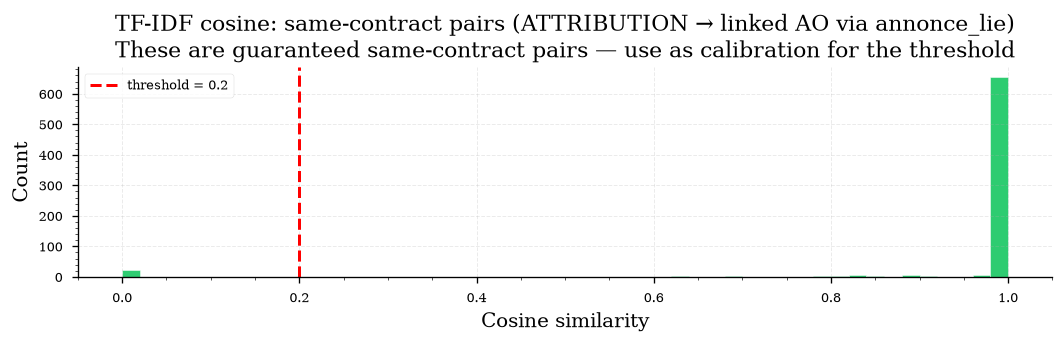


Note: if most same-contract pairs fall below 0.30, consider lowering MIN_TEXT_SIMILARITY.


In [23]:
# Only ATTRIBUTION notices whose annonce_lie points to an AO in our dataset
attr_cal = attr[
    attr["annonce_lie"].astype(str).str.strip().isin(ao_idweb_set) &
    attr["objet"].notna()
].copy()
attr_cal["objet_normalized"] = attr_cal["objet"].map(normalize_objet)

if len(attr_cal) > 0:
    attr_tfidf = vectorizer.transform(attr_cal["objet_normalized"])

    cal_scores = []
    for i, (_, row) in enumerate(attr_cal.iterrows()):
        linked_id = str(row["annonce_lie"]).strip()
        j = idweb_to_idx.get(linked_id)
        if j is not None:
            score = float(cosine_similarity(attr_tfidf[i], tfidf_matrix[j])[0, 0])
            cal_scores.append(score)

    cal_s = pd.Series(cal_scores)
    print(f"Calibration pairs (same-contract ATTRIBUTION→AO): {len(cal_scores):,}")
    print(cal_s.describe().round(3))
    print(f"\n% above threshold 0.30: {(cal_s >= 0.30).mean():.1%}")
    print(f"% above threshold 0.20: {(cal_s >= 0.20).mean():.1%}")
    print(f"% above threshold 0.10: {(cal_s >= 0.10).mean():.1%}")

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.hist(cal_scores, bins=50, color="#2ecc71", edgecolor="white", linewidth=0.3)
    ax.axvline(MIN_TEXT_SIMILARITY, color="red", linestyle="--",
               label=f"threshold = {MIN_TEXT_SIMILARITY}")
    ax.set(title="TF-IDF cosine: same-contract pairs (ATTRIBUTION → linked AO via annonce_lie)\n"
                 "These are guaranteed same-contract pairs — use as calibration for the threshold",
           xlabel="Cosine similarity", ylabel="Count")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("\nNote: if most same-contract pairs fall below 0.30, consider lowering MIN_TEXT_SIMILARITY.")
else:
    print("No calibration pairs available.")

Loading sentence-transformers model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

ST embeddings shape: (1933, 384)



ST calibration — 728 same-contract pairs (annonce_lie):
count    728.000
mean       0.968
std        0.138
min        0.088
25%        1.000
50%        1.000
75%        1.000
max        1.000
dtype: float64

% above threshold 0.20: 98.2%
% above threshold 0.30: 97.4%


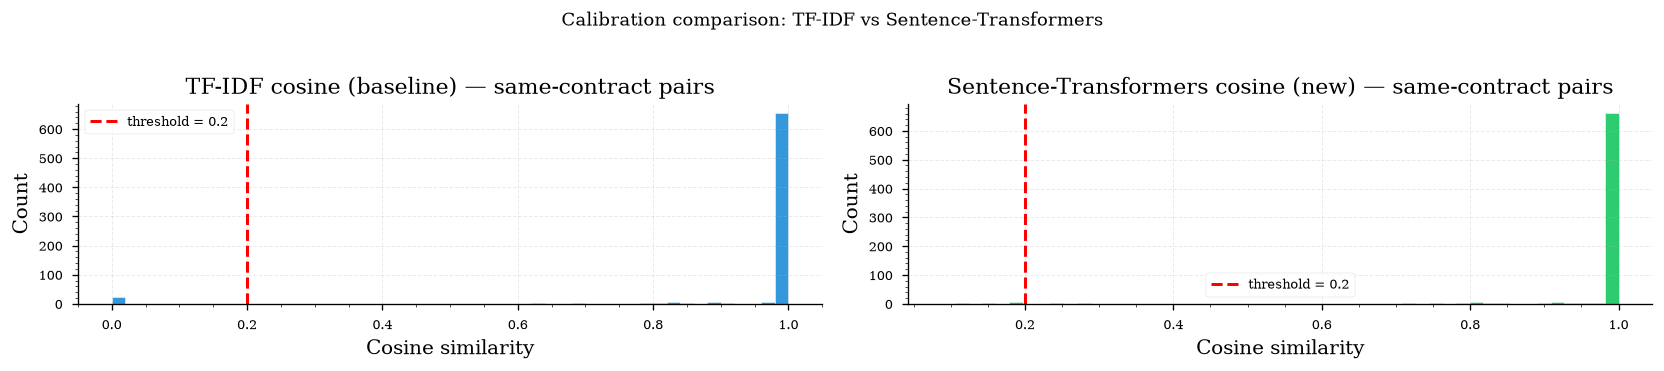

In [24]:
# Sentence-Transformers embeddings
# Model: paraphrase-multilingual-MiniLM-L12-v2 (multilingual, 384-dim)
# Semantic similarity beyond lexical overlap — addresses TEXT_MISMATCH failures

print("Loading sentence-transformers model...")
st_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

texts = ao["objet_normalized"].fillna("").tolist()
st_embeddings = st_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(f"ST embeddings shape: {st_embeddings.shape}")

# Calibration on same-contract pairs (annonce_lie)
if len(attr_cal) > 0:
    attr_texts = attr_cal["objet_normalized"].fillna("").tolist()
    attr_st_emb = st_model.encode(attr_texts, batch_size=64, normalize_embeddings=True)

    st_cal_scores = []
    for i, (_, row) in enumerate(attr_cal.iterrows()):
        linked_id = str(row["annonce_lie"]).strip()
        j = idweb_to_idx.get(linked_id)
        if j is not None:
            st_cal_scores.append(float(np.dot(attr_st_emb[i], st_embeddings[j])))

    st_cal_s = pd.Series(st_cal_scores)
    print(f"\nST calibration — {len(st_cal_scores):,} same-contract pairs (annonce_lie):")
    print(st_cal_s.describe().round(3))
    print(f"\n% above threshold 0.20: {(st_cal_s >= 0.20).mean():.1%}")
    print(f"% above threshold 0.30: {(st_cal_s >= 0.30).mean():.1%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    for ax, (scores, title, color) in zip(axes, [
        (cal_scores,     "TF-IDF cosine (baseline)",          "#3498db"),
        (st_cal_scores,  "Sentence-Transformers cosine (new)", "#2ecc71"),
    ]):
        ax.hist(scores, bins=50, color=color, edgecolor="white", linewidth=0.3)
        ax.axvline(MIN_TEXT_SIMILARITY, color="red", linestyle="--",
                   label=f"threshold = {MIN_TEXT_SIMILARITY}")
        ax.set(title=f"{title} — same-contract pairs",
               xlabel="Cosine similarity", ylabel="Count")
        ax.legend()
    plt.suptitle("Calibration comparison: TF-IDF vs Sentence-Transformers", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    st_cal_scores = []
    print("No calibration pairs available.")

---
## 3. Renewal Linking — Candidate Generation

### Algorithm design

**Key change from the existing baseline**: the previous script (`task_boamp_full_survival.py`) groups by `[buyer_key, cpv_div2]`, making any CPV difference between the original contract and its renewal fatal — even if the same buyer is procuring essentially the same service re-classified under a slightly different CPV. Here, we:

1. **Group by `buyer_key` only** (single key constraint)
2. **Use CPV as a hierarchy-based scored component** (1.00 → 0.80 → 0.60 → 0.40 → 0.20 → 0.00 by matching depth, following the official CPV nomenclature: division / group / class / category / full code)
3. **Use Sentence-Transformers cosine** (`paraphrase-multilingual-MiniLM-L12-v2`) instead of TF-IDF — captures semantic meaning, not just lexical overlap
4. **Composite score** = weighted sum of the interpretable components

#### Composite score formula

When the CPV code is present on both notices:

```
composite = 0.40 × text_similarity
          + 0.25 × cpv_compatibility
          + 0.20 × temporal_proximity
          + 0.15 × buyer_match        (always 1.0 within the same buyer group)
```

When the CPV code is **missing** on either notice, CPV is *excluded* from the composite and the remaining component weights are renormalized by their sum (0.40 + 0.20 + 0.15 = 0.75):

```
composite = (0.40 × text_similarity + 0.20 × temporal_proximity + 0.15 × buyer_match) / 0.75
```

Missing CPV is therefore never assigned an arbitrary neutral 0.5. Each component is in [0, 1] so the composite is also in [0, 1].

In [25]:
def compute_temporal_score(
    gap_months: float,
    expected_duration: float,
    window: float = TEMPORAL_WINDOW_MONTHS,
) -> float:
    """Score 1.0 at exact match, 0.0 at the window boundary (linear decay)."""
    deviation = abs(gap_months - expected_duration)
    if deviation > window:
        return 0.0
    return round(1.0 - deviation / window, 4)


def _is_valid_cpv(code) -> bool:
    return isinstance(code, str) and len(code) >= 2


def compute_cpv_score(src_cpv, cand_cpv) -> float:
    """Hierarchy-based CPV compatibility (official CPV nomenclature).

    CPV is hierarchical: 2 digits = division, 3 = group, 4 = class,
    5 = category, 8 = full code (the 9th digit after a dash is only a check digit).

        1.00  same full 8-digit code
        0.80  same 5-digit category
        0.60  same 4-digit class
        0.40  same 3-digit group
        0.20  same 2-digit division
        0.00  valid CPVs but different division
        NaN   one or both CPVs missing  (excluded from the composite, NOT 0.5)

    Generic / catch-all codes (ending in 000000, e.g. 72000000) carry no
    sub-division signal, so they are capped at the division level:
        generic & same division      -> at most 0.20
        generic & different division  -> 0.00
    """
    if not _is_valid_cpv(src_cpv) or not _is_valid_cpv(cand_cpv):
        return np.nan

    same_div = src_cpv[:2] == cand_cpv[:2]

    if src_cpv.endswith("000000") or cand_cpv.endswith("000000"):
        return 0.20 if same_div else 0.0

    if src_cpv[:8] == cand_cpv[:8]:
        return 1.00
    if src_cpv[:5] == cand_cpv[:5]:
        return 0.80
    if src_cpv[:4] == cand_cpv[:4]:
        return 0.60
    if src_cpv[:3] == cand_cpv[:3]:
        return 0.40
    if same_div:
        return 0.20
    return 0.0


print("Helper functions defined: compute_temporal_score, compute_cpv_score")


Helper functions defined: compute_temporal_score, compute_cpv_score


In [26]:
# ── Candidate generation loop ────────────────────────────────────
# SOURCE set  : ELIGIBLE AO only (renewal window within study period)
# CANDIDATE set: ALL AO from the same buyer published later than the source
#   — a right-censored AO cannot be a source (no time to observe its renewal)
#     but it CAN be a renewal candidate for an earlier eligible AO
ao["_row_idx"] = ao["idweb"].astype(str).map(idweb_to_idx)
ao_elig = ao[ao["eligible"]].copy().reset_index(drop=True)
ao_elig["_row_idx"] = ao_elig["idweb"].astype(str).map(idweb_to_idx)

# Full AO index for candidate lookup (all notices, not just eligible)
ao_all_by_buyer = {k: grp for k, grp in ao.groupby("buyer_key", dropna=False, sort=False)}

candidates = []

for buyer_key, src_grp in ao_elig.groupby("buyer_key", dropna=False, sort=False):
    all_grp = ao_all_by_buyer.get(buyer_key, src_grp)

    if len(all_grp) < 2:
        continue
    all_grp = all_grp.sort_values("contract_start")

    for _, src in src_grp.iterrows():
        start = src["contract_start"]
        if pd.isna(start):
            continue

        dur     = src["dur_used"]
        exp_end = start + pd.to_timedelta(dur * 30.44, unit="D")
        win_open  = exp_end - pd.to_timedelta(TEMPORAL_WINDOW_MONTHS * 30.44, unit="D")
        win_close = exp_end + pd.to_timedelta(TEMPORAL_WINDOW_MONTHS * 30.44, unit="D")

        # Pool: ANY later AO from the same buyer within the temporal window
        pool = all_grp[
            (all_grp["contract_start"] > start) &
            (all_grp["contract_start"] >= win_open) &
            (all_grp["contract_start"] <= win_close)
        ]

        if pool.empty:
            continue

        src_idx = src["_row_idx"]

        for _, cand in pool.iterrows():
            gap = (cand["contract_start"] - start).days / 30.44
            cand_idx = cand["_row_idx"]

            # Text similarity (Sentence-Transformers cosine = dot product on unit-norm embeddings)
            if src_idx is not None and cand_idx is not None and src_idx != cand_idx:
                text_sim = float(np.dot(st_embeddings[src_idx], st_embeddings[cand_idx]))
            else:
                text_sim = 0.0

            cpv_s      = compute_cpv_score(src["cpv_clean"], cand["cpv_clean"])
            temporal_s = compute_temporal_score(gap, dur)
            buyer_s    = 1.0

            # Missing CPV (cpv_s is NaN) is EXCLUDED from the composite and the
            # remaining component weights are renormalized — it is never given an
            # arbitrary neutral 0.5.
            cpv_used = not (cpv_s is None or (isinstance(cpv_s, float) and np.isnan(cpv_s)))
            if cpv_used:
                composite = (
                    W_TEXT     * text_sim +
                    W_CPV      * cpv_s +
                    W_TEMPORAL * temporal_s +
                    W_BUYER    * buyer_s
                )
            else:
                avail = W_TEXT + W_TEMPORAL + W_BUYER   # 0.75
                composite = (
                    W_TEXT     * text_sim +
                    W_TEMPORAL * temporal_s +
                    W_BUYER    * buyer_s
                ) / avail

            candidates.append({
                "src_idweb":              src["idweb"],
                "src_buyer_key":          buyer_key,
                "src_cpv":                src["cpv_clean"],
                "src_contract_start":     start,
                "src_duration_months":    dur,
                "src_objet":              src["objet"],
                "cand_idweb":             cand["idweb"],
                "cand_contract_start":    cand["contract_start"],
                "cand_cpv":               cand["cpv_clean"],
                "cand_objet":             cand["objet"],
                "gap_months":             round(gap, 2),
                "buyer_match_score":      buyer_s,
                "cpv_match_score":        round(cpv_s, 3) if cpv_used else np.nan,
                "cpv_used_in_score":      cpv_used,
                "text_similarity_score":  round(text_sim, 4),
                "temporal_proximity_score": round(temporal_s, 4),
                "composite_score":        round(composite, 4),
            })

candidates_df = pd.DataFrame(candidates)
print(f"Raw candidate pairs generated:          {len(candidates_df):,}")
if len(candidates_df) > 0:
    print(f"Eligible AO with ≥1 temporal candidate: {candidates_df['src_idweb'].nunique():,}")
    print(f"(Source = eligible AO only; candidates include all AO from same buyer)")


Raw candidate pairs generated:          3,989
Eligible AO with ≥1 temporal candidate: 719
(Source = eligible AO only; candidates include all AO from same buyer)


### Score weight rationale

| Component | Weight | Rationale |
|---|---|---|
| `text_similarity_score` | **0.40** | Highest weight — captures whether the contract is about the same service. Sentence-Transformers (`paraphrase-multilingual-MiniLM-L12-v2`) cosine on `objet_normalized`. |
| `cpv_match_score` | **0.25** | Hierarchy-based: 1.00 (same 8-digit code) → 0.80 (category) → 0.60 (class) → 0.40 (group) → 0.20 (division) → 0.00 (different division). Generic catch-all codes (ending `000000`) are capped at 0.20. **Missing CPV is excluded** and the remaining weights are renormalized (never scored 0.5). |
| `temporal_proximity_score` | **0.20** | Rewards candidates close to the expected renewal date without hard-excluding distant ones (hard filters come later). |
| `buyer_match_score` | **0.15** | Always 1.0 within the groupby loop. Kept explicit so all weights sum to 1.0 and the score is fully transparent. Future improvement: cross-buyer linking would give this component real variance. |

---
## 4. Candidate Filtering

We apply three hard filters to remove clearly impossible links, then select the best candidate per source AO.

In [27]:
if len(candidates_df) == 0:
    print("No candidates to filter.")
    filtered = pd.DataFrame()
else:
    n_raw = len(candidates_df)

    # Hard filters
    # Note: CPV is intentionally NOT a hard filter here — it is a scored component (weight 0.25).
    # Requiring CPV match as a hard gate would exclude legitimate renewals where the buyer
    # re-classified the service under a slightly different CPV code.
    f1 = candidates_df["text_similarity_score"] >= MIN_TEXT_SIMILARITY
    f2 = candidates_df["gap_months"].between(MIN_GAP_MONTHS, MAX_GAP_MONTHS)

    print(f"Candidates before filtering:                {n_raw:,}")
    print(f"Pass text similarity ≥ {MIN_TEXT_SIMILARITY}:  {f1.sum():,} ({100*f1.mean():.1f}%)")
    print(f"Pass gap in [{MIN_GAP_MONTHS:.0f}, {MAX_GAP_MONTHS:.0f}] months:   {f2.sum():,} ({100*f2.mean():.1f}%)")

    filtered = candidates_df[f1 & f2].copy()
    print(f"\nAfter all filters:                          {len(filtered):,}")
    if len(filtered) > 0:
        print(f"Unique source AO with a surviving candidate: {filtered['src_idweb'].nunique():,}")

    # Informational: CPV breakdown among surviving candidates (CPV is a scored
    # component, not a hard filter). Missing CPV is excluded from the composite.
    if len(filtered) > 0:
        cpv_pos  = int((filtered["cpv_match_score"] > 0.0).sum())
        cpv_zero = int((filtered["cpv_match_score"] == 0.0).sum())
        cpv_miss = int(filtered["cpv_match_score"].isna().sum())
        print(f"\n[Info] Of the {len(filtered):,} passing text+gap filters:")
        print(f"  {cpv_pos:,} have CPV > 0 (same division or better)")
        print(f"  {cpv_zero:,} have CPV = 0 (valid but different division) — kept because CPV is a scored component")
        print(f"  {cpv_miss:,} have CPV missing (excluded from composite; weights renormalized)")


Candidates before filtering:                3,989
Pass text similarity ≥ 0.2:  3,282 (82.3%)
Pass gap in [6, 72] months:   3,878 (97.2%)

After all filters:                          3,201
Unique source AO with a surviving candidate: 665

[Info] Of the 3,201 passing text+gap filters:
  1,196 have CPV > 0 (same division or better)
  1,920 have CPV = 0 (valid but different division) — kept because CPV is a scored component
  85 have CPV missing (excluded from composite; weights renormalized)


In [28]:
# Best candidate selection: one link per source AO
if len(filtered) > 0:
    best_links = (
        filtered
        .sort_values("composite_score", ascending=False)
        .drop_duplicates(subset=["src_idweb"], keep="first")
        .copy()
    )
    print(f"Best-link selection: {len(best_links):,} links (one per source AO)")
    print("\nComposite score distribution:")
    print(best_links["composite_score"].describe().round(3))
else:
    best_links = pd.DataFrame()

# Save all filtered candidates (before best-selection)
filtered.to_csv(OUTPUTS / "boamp_renewal_candidates.csv", index=False)
print(f"\nSaved {len(filtered):,} candidate pairs → outputs/boamp_renewal_candidates.csv")

Best-link selection: 665 links (one per source AO)

Composite score distribution:
count    665.000
mean       0.554
std        0.144
min        0.243
25%        0.453
50%        0.529
75%        0.626
max        0.996
Name: composite_score, dtype: float64

Saved 3,201 candidate pairs → outputs/boamp_renewal_candidates.csv


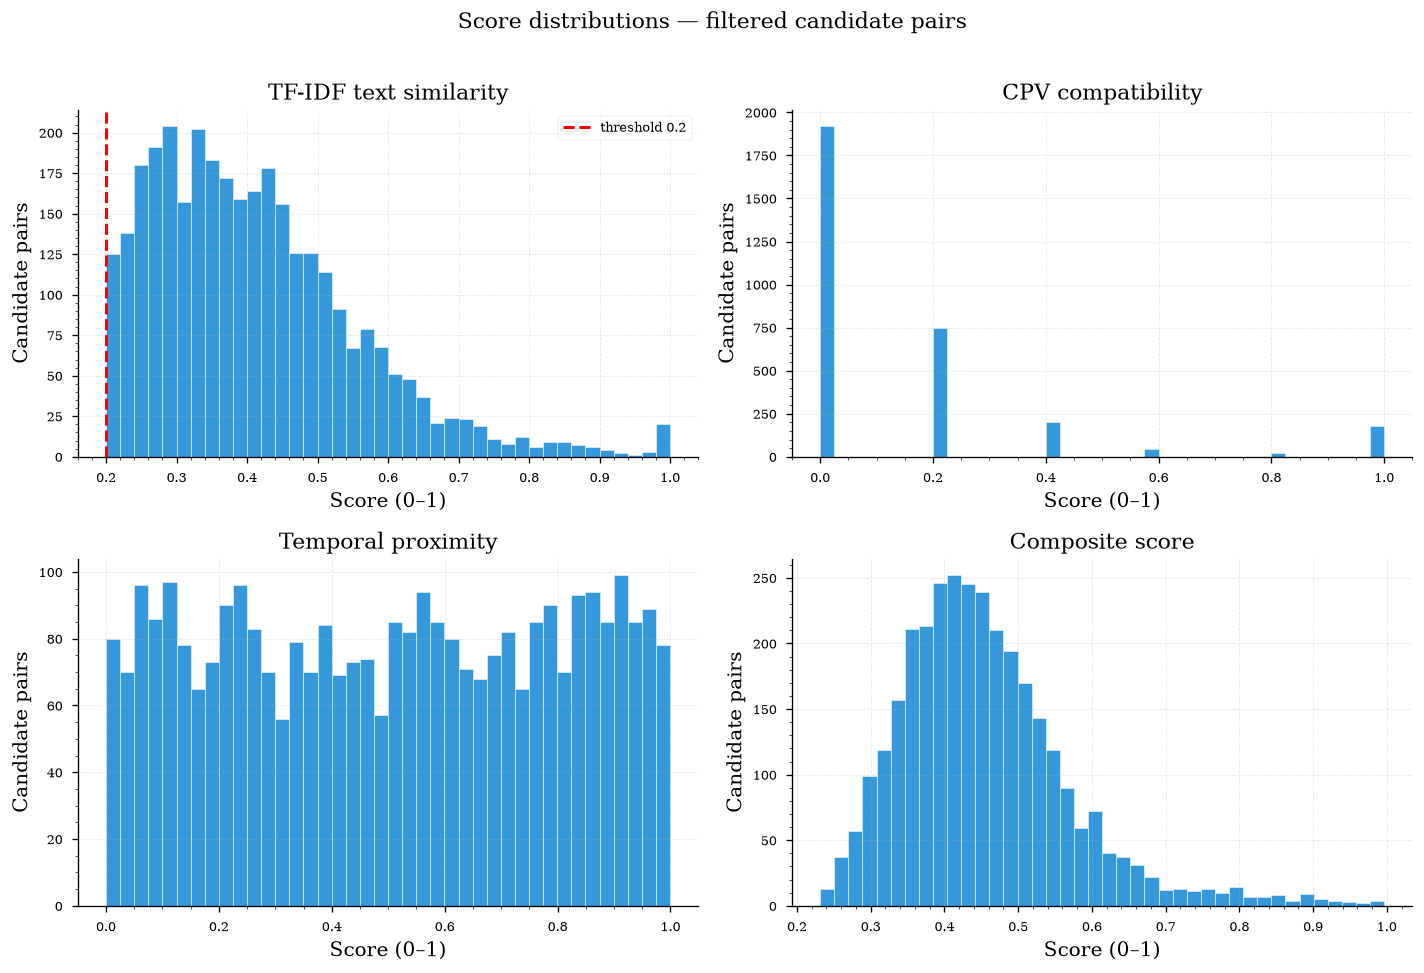

In [29]:
if len(filtered) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for ax, (col, title) in zip(axes.flat, [
        ("text_similarity_score",    "TF-IDF text similarity"),
        ("cpv_match_score",          "CPV compatibility"),
        ("temporal_proximity_score", "Temporal proximity"),
        ("composite_score",          "Composite score"),
    ]):
        ax.hist(filtered[col], bins=40, color="#3498db", edgecolor="white", linewidth=0.3)
        ax.set(title=title, xlabel="Score (0–1)", ylabel="Candidate pairs")

    axes[0, 0].axvline(MIN_TEXT_SIMILARITY, color="red", linestyle="--",
                       label=f"threshold {MIN_TEXT_SIMILARITY}")
    axes[0, 0].legend(fontsize=8)

    plt.suptitle("Score distributions — filtered candidate pairs", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

---
## 5. Linking Rate Calculation

We build the final `links_df` table: one row per eligible AO, with `event=1` if a renewal link was found and `event=0` otherwise.

### Denominator and numerator definitions

- **Eligible** (denominator): AO whose renewal search window (`estimated_end_date ± 6 months`) falls within the study period. Right-censored AO are excluded — they cannot be linked regardless of algorithm quality.
- **Linked** (numerator): eligible AO for which the best candidate passed all hard filters (text ≥ 0.20, gap in [6, 72] months) and has the highest composite score.

In [30]:
linked_src_ids = set(best_links["src_idweb"].astype(str)) if len(best_links) > 0 else set()
best_by_src = best_links.set_index("src_idweb") if len(best_links) > 0 else pd.DataFrame()

link_records = []
for _, row in ao_elig.iterrows():
    idweb = str(row["idweb"])
    start = row["contract_start"]

    if idweb in linked_src_ids:
        lk = best_by_src.loc[idweb]
        link_records.append({
            "contract_id":              f"BOAMP:{idweb}",
            "buyer_key":                row["buyer_key"],
            "cpv_div2":                 row["cpv_div2"],
            "category_label":           row.get("category_label"),
            "contract_start":           start.date().isoformat() if pd.notna(start) else None,
            "declared_duration_months": row["dur_used"],
            "dur_was_imputed":          row["dur_was_imputed"],
            "estimated_end_date":       row["estimated_end_date_v2"].date().isoformat()
                                        if pd.notna(row["estimated_end_date_v2"]) else None,
            "event":                    1,
            "renewal_contract_id":      f"BOAMP:{lk['cand_idweb']}",
            "observed_duration_months": lk["gap_months"],
            "composite_score":          lk["composite_score"],
            "text_similarity":          lk["text_similarity_score"],
            "cpv_match_score":          lk["cpv_match_score"],
            "cpv_used_in_score":        bool(lk["cpv_used_in_score"]),
            "temporal_score":           lk["temporal_proximity_score"],
            "start_date_source":        row["start_date_source"],
            "link_method":              "sentence_transformers",
        })
    else:
        obs_dur = (STUDY_END - start).days / 30.44 if pd.notna(start) else None
        link_records.append({
            "contract_id":              f"BOAMP:{idweb}",
            "buyer_key":                row["buyer_key"],
            "cpv_div2":                 row["cpv_div2"],
            "category_label":           row.get("category_label"),
            "contract_start":           start.date().isoformat() if pd.notna(start) else None,
            "declared_duration_months": row["dur_used"],
            "dur_was_imputed":          row["dur_was_imputed"],
            "estimated_end_date":       row["estimated_end_date_v2"].date().isoformat()
                                        if pd.notna(row["estimated_end_date_v2"]) else None,
            "event":                    0,
            "renewal_contract_id":      None,
            "observed_duration_months": round(obs_dur, 2) if obs_dur is not None else None,
            "composite_score":          None,
            "text_similarity":          None,
            "cpv_match_score":          None,
            "cpv_used_in_score":        None,
            "temporal_score":           None,
            "start_date_source":        row["start_date_source"],
            "link_method":              "none",
        })

links_df = pd.DataFrame(link_records)

# Enrich with covariates from boamp_full_clean.csv for Phase 2 Cox model
_clean = pd.read_csv(PROCESSED / "boamp_full_clean.csv",
                     usecols=['idweb', 'amount_clean', 'flag_amount_zero',
                              'flag_amount_tiny', 'flag_amount_ceiling',
                              'type_procedure', 'type_marche'])
links_df['_idweb'] = links_df['contract_id'].str.replace('BOAMP:', '', regex=False)
links_df = links_df.merge(_clean, left_on='_idweb', right_on='idweb', how='left').drop(
    columns=['_idweb', 'idweb'])

links_df.to_csv(OUTPUTS / "boamp_renewal_links.csv", index=False)
print(f"Saved {len(links_df):,} records × {links_df.shape[1]} columns → outputs/boamp_renewal_links.csv")


Saved 1,210 records × 24 columns → outputs/boamp_renewal_links.csv


### 5.x Strict high-confidence diagnostic (score margin)

The linker keeps the single highest-scoring candidate per source contract. To gauge how
*separable* that winner is, we compute, per source, the margin between the best and the
second-best composite score:

$$\text{score\_margin} = \text{best\_composite\_score} - \text{second\_best\_composite\_score}$$

and a conservative `high_confidence_strict` flag requiring **both** a high absolute score
(`composite_score >= 0.70`) **and** a clear margin (`score_margin >= 0.05`).

> **Note.** The strict high-confidence definition is *not* a new ground truth. It is a
> conservative sensitivity definition requiring both a high absolute score and a clear
> margin over the second-best candidate. Single-candidate matches have an undefined
> margin (`NaN`) and are therefore **never** auto-marked strict; they are tracked
> separately via `single_candidate_match`.

In [31]:
# Strict high-confidence diagnostics (score margin)
# Operationalize the score-disambiguation diagnostic discussed in the report:
#     score_margin = best_composite_score - second_best_composite_score
# Logic lives in scripts/link_confidence.py (single source of truth, also used by
# scripts/task10_link_confidence_diagnostics.py).
from link_confidence import (
    DIAGNOSTIC_COLUMNS,
    compute_link_confidence,
    format_summary,
)

# `filtered` is the post-filter candidate pool (== boamp_renewal_candidates.csv) from
# which the best link is chosen; the margin is computed over that same pool.
links_df, link_diagnostics, conf_stats = compute_link_confidence(filtered, links_df)

# Re-save the modeling dataset, now with the six diagnostic columns appended.
links_df.to_csv(OUTPUTS / "boamp_renewal_links.csv", index=False)
link_diagnostics.to_csv(OUTPUTS / "boamp_link_confidence_diagnostics.csv", index=False)

print(format_summary(conf_stats))
print(f"\nAdded columns: {DIAGNOSTIC_COLUMNS}")
print(f"Saved {len(links_df):,} rows -> outputs/boamp_renewal_links.csv (augmented)")
print(f"Saved {len(link_diagnostics):,} rows -> outputs/boamp_link_confidence_diagnostics.csv")

  STRICT HIGH-CONFIDENCE LINK DIAGNOSTICS
  event=1 links:                             665
  composite_score >= 0.70:                    99  (14.89%)
  multi-candidate links:                     501
  score_margin >= 0.05 (multi-candidate):    282  (56.29% of multi)
  high_confidence_strict:                     75  (11.28% of events)
  single-candidate matches:                  164
  ambiguous (multi, margin < 0.05):          219
  NOTE: high_confidence_strict is a conservative sensitivity
  definition, NOT a new ground truth.

Added columns: ['best_composite_score', 'second_best_composite_score', 'score_margin', 'n_candidates_for_source', 'single_candidate_match', 'high_confidence_strict']
Saved 1,210 rows -> outputs/boamp_renewal_links.csv (augmented)
Saved 1,210 rows -> outputs/boamp_link_confidence_diagnostics.csv


In [32]:
# Modeling dataset — boamp_renewal_links.csv
# One row per eligible APPEL_OFFRE; this is the input to the survival model
print(f"Shape: {links_df.shape[0]:,} rows × {links_df.shape[1]} columns")
print(f"Event rate: {links_df['event'].sum():,} / {len(links_df):,} = {links_df['event'].mean()*100:.1f}%")
print(f"\nColumn dtypes:")
print(links_df.dtypes.to_string())
print(f"\nNumeric summary:")
display(links_df[[
    'declared_duration_months', 'observed_duration_months',
    'composite_score', 'text_similarity', 'cpv_match_score', 'temporal_score'
]].describe().round(3))
print(f"\nFirst 10 rows (event=1 linked, event=0 censored):")
links_df.head(10)

Shape: 1,210 rows × 30 columns
Event rate: 665 / 1,210 = 55.0%

Column dtypes:
contract_id                     object
buyer_key                       object
cpv_div2                        object
category_label                  object
contract_start                  object
declared_duration_months       float64
dur_was_imputed                   bool
estimated_end_date              object
event                            int64
renewal_contract_id             object
observed_duration_months       float64
composite_score                float64
text_similarity                float64
cpv_match_score                float64
cpv_used_in_score               object
temporal_score                 float64
start_date_source               object
link_method                     object
type_procedure                  object
type_marche                     object
flag_amount_zero                 int64
flag_amount_tiny                 int64
flag_amount_ceiling              int64
amount_clean            

,declared_duration_months,observed_duration_months,composite_score,text_similarity,cpv_match_score,temporal_score
count,1210.000,1210.000,665.000,665.000,622.000,665.000
mean,31.673,50.387,0.554,0.493,0.305,0.633
std,17.820,29.687,0.144,0.192,0.376,0.278
min,1.000,6.010,0.243,0.200,0.000,0.007
25%,12.000,25.100,0.453,0.344,0.000,0.426
50%,36.000,48.175,0.529,0.460,0.200,0.697
75%,48.000,69.120,0.626,0.590,0.400,0.872
max,90.000,118.000,0.996,1.000,1.000,0.999



First 10 rows (event=1 linked, event=0 censored):


,contract_id,buyer_key,cpv_div2,category_label,contract_start,declared_duration_months,dur_was_imputed,estimated_end_date,event,renewal_contract_id,...,flag_amount_zero,flag_amount_tiny,flag_amount_ceiling,amount_clean,best_composite_score,second_best_composite_score,score_margin,n_candidates_for_source,single_candidate_match,high_confidence_strict
0,BOAMP:15-30947,NAME:smictom de la vallee de l authion,48.0,Software & Applications,2015-03-02,12.0,False,2016-03-01,0,None,...,0,0,0,150000.0,NaN,NaN,NaN,0,False,False
1,BOAMP:15-31464,SIREN:285300018,NaN,Unknown,2015-03-02,36.0,False,2018-03-01,1,BOAMP:17-176560,...,0,0,0,NaN,0.7266,NaN,NaN,1,True,False
2,BOAMP:15-31513,SIREN:214401432,38.0,Unknown,2015-03-02,48.0,False,2019-03-02,1,BOAMP:19-87143,...,0,0,0,NaN,0.4408,NaN,NaN,1,True,False
3,BOAMP:15-20937,SIREN:214401093,44.0,Unknown,2015-03-03,48.0,False,2019-03-03,1,BOAMP:19-17307,...,0,0,0,NaN,0.8469,0.4056,0.4413,2,False,True
4,BOAMP:15-32168,SIREN:234400034,72.0,IT Services & Consulting,2015-07-21,24.0,False,2017-07-20,1,BOAMP:17-48788,...,0,0,0,NaN,0.5966,0.5589,0.0377,18,False,False
5,BOAMP:15-31641,SIREN:784301525,NaN,Data & AI,2015-03-04,12.0,False,2016-03-03,0,None,...,0,0,0,800000.0,NaN,NaN,NaN,0,False,False
6,BOAMP:15-31797,NAME:acoss,72.0,IT Services & Consulting,2015-03-04,12.0,False,2016-03-03,0,None,...,0,0,0,NaN,NaN,NaN,NaN,0,False,False
7,BOAMP:15-33241,SIREN:264400136,32.0,Telecom & Networks,2015-09-11,48.0,True,2019-09-11,1,BOAMP:20-19986,...,0,0,0,NaN,0.6690,0.4906,0.1784,3,False,False
8,BOAMP:15-33752,SIREN:234400034,72.0,Cybersecurity,2015-06-29,48.0,True,2019-06-29,1,BOAMP:19-41115,...,0,0,0,NaN,0.4612,0.4552,0.0060,8,False,False
9,BOAMP:15-34520,NAME:d angers,32.0,Telecom & Networks,2015-03-06,48.0,True,2019-03-06,0,None,...,0,0,0,NaN,NaN,NaN,NaN,0,False,False


In [33]:
n_total_ao  = len(ao)
n_censored  = ao["right_censored"].sum()
n_eligible  = int(len(ao_elig))
n_linked    = int(links_df["event"].sum())
n_unlinked  = n_eligible - n_linked

rate_elig   = n_linked / n_eligible if n_eligible > 0 else 0.0
rate_all    = n_linked / n_total_ao  if n_total_ao > 0 else 0.0

print("=" * 55)
print("  LINKING RATE SUMMARY")
print("=" * 55)
print(f"  Total APPEL_OFFRE notices:            {n_total_ao:>6,}")
print(f"  Right-censored (window > Dec 2024):   {n_censored:>6,}")
print(f"  ELIGIBLE (denominator):               {n_eligible:>6,}")
print(f"    Linked renewals (event=1):           {n_linked:>6,}")
print(f"    Unlinked (censored / not found):     {n_unlinked:>6,}")
print("=" * 55)
print(f"  Linking rate (eligible denominator):   {rate_elig:.1%}  ← PRIMARY")
print(f"  Linking rate (all AO denominator):     {rate_all:.1%}")
print(f"  Previous baseline (Jaccard, all AO, W=6):  7.6%")
print("=" * 55)

# Save summary stats
stats = pd.DataFrame([{
    "total_ao": n_total_ao, "right_censored": n_censored,
    "eligible_ao": n_eligible, "linked_events": n_linked, "unlinked": n_unlinked,
    "linking_rate_eligible_pct": round(100 * rate_elig, 2),
    "linking_rate_all_pct":      round(100 * rate_all, 2),
    "prev_baseline_pct": 7.6,
    "min_text_threshold": MIN_TEXT_SIMILARITY,
    "temporal_window_months": TEMPORAL_WINDOW_MONTHS,
    "default_duration_months": DEFAULT_DURATION_MONTHS,
}])
stats.to_csv(OUTPUTS / "boamp_linking_stats.csv", index=False)
print(f"\nSaved summary → outputs/boamp_linking_stats.csv")

  LINKING RATE SUMMARY
  Total APPEL_OFFRE notices:             1,933
  Right-censored (window > Dec 2024):      723
  ELIGIBLE (denominator):                1,210
    Linked renewals (event=1):              665
    Unlinked (censored / not found):        545
  Linking rate (eligible denominator):   55.0%  ← PRIMARY
  Linking rate (all AO denominator):     34.4%
  Previous baseline (Jaccard, all AO, W=6):  7.6%

Saved summary → outputs/boamp_linking_stats.csv


In [34]:
# Before vs After: TF-IDF vs Sentence-Transformers
TFIDF_BASELINE = {"method": "TF-IDF cosine",        "linked": 279, "eligible": 1100, "rate": 25.36}
ST_RESULT      = {"method": "Sentence-Transformers", "linked": n_linked,
                  "eligible": n_eligible, "rate": round(n_linked / n_eligible * 100, 2)}

comparison = pd.DataFrame([TFIDF_BASELINE, ST_RESULT])
comparison["delta_pp"] = comparison["rate"] - TFIDF_BASELINE["rate"]

print("=" * 58)
print("  BEFORE vs AFTER — Text Similarity Method Comparison")
print("=" * 58)
print(comparison[["method", "linked", "eligible", "rate", "delta_pp"]].to_string(index=False))
print("=" * 58)
delta = ST_RESULT["rate"] - TFIDF_BASELINE["rate"]
print(f"  Change: {delta:+.2f} percentage points  (threshold={MIN_TEXT_SIMILARITY}, window=±{TEMPORAL_WINDOW_MONTHS}m)")

  BEFORE vs AFTER — Text Similarity Method Comparison
               method  linked  eligible  rate  delta_pp
        TF-IDF cosine     279      1100 25.36       0.0
Sentence-Transformers     665      1210 54.96      29.6
  Change: +29.60 percentage points  (threshold=0.2, window=±6.0m)


In [35]:
# Linking rate breakdown by segment
def rate_table(df, groupby_col, label):
    t = (
        df.groupby(groupby_col, dropna=False)
        .agg(n=("event", "count"), linked=("event", "sum"))
        .assign(linking_rate_pct=lambda d: (100 * d["linked"] / d["n"]).round(1))
        .sort_values("n", ascending=False)
        .reset_index()
    )
    print(f"\nLinking rate by {label}:")
    print(t.to_string(index=False))
    return t

links_df["pub_year"] = pd.to_datetime(links_df["contract_start"], errors="coerce").dt.year

rate_table(links_df, "cpv_div2", "CPV division")
rate_table(links_df, "category_label", "technology category")
rate_table(links_df, "pub_year", "publication year");


Linking rate by CPV division:
cpv_div2   n  linked  linking_rate_pct
    72.0 461     283              61.4
    48.0 226     142              62.8
    32.0 196      98              50.0
    35.0  84      37              44.0
    45.0  64      23              35.9
     NaN  56      23              41.1
    30.0  20       7              35.0
    39.0  16       9              56.2
    79.0  14      10              71.4
    50.0  11       5              45.5
    64.0  10       4              40.0
    44.0   8       3              37.5
    18.0   7       4              57.1
    71.0   6       1              16.7
    37.0   4       3              75.0
    38.0   4       2              50.0
    31.0   3       2              66.7
    90.0   3       3             100.0
    42.0   3       3             100.0
    75.0   3       1              33.3
    92.0   2       0               0.0
    43.0   2       0               0.0
    34.0   2       1              50.0
    15.0   1       0             

---
## 6. Missed Match and Bias Assessment

We analyze **where** the algorithm fails and **whether the linked sample is biased** relative to the full eligible AO population.

### 6.1 Failure funnel

Each eligible unlinked AO falls into one of three failure categories (ordered by diagnosis priority):

- **NO_TEMPORAL_PARTNER**: the buyer issued no later AO within the temporal window from the full AO dataset — structurally uncoverable. No algorithm improvement can fix this.
- **CPV_MISMATCH** *(diagnostic)*: a temporal candidate exists but ALL candidates from the same buyer have a **valid but incompatible** CPV division (score = 0.0). Notices whose CPV is *missing* are not counted here, since CPV is excluded from their composite. These are still evaluated for text similarity, but CPV = 0 in the composite makes high-score links rarer.
- **TEXT_MISMATCH**: a temporal candidate exists (possibly with compatible CPV), but Sentence-Transformers cosine similarity < 0.20 for all candidates. With TF-IDF this was the main bottleneck; Sentence-Transformers reduces this substantially by capturing semantic meaning beyond word overlap.

Note: CPV is **not** a hard filter in this algorithm — it is a scored component (weight 0.25). CPV_MISMATCH is a diagnostic label, not a rejection reason.

Failure breakdown (eligible AO):
  LINKED                   :   665  (55.0%)
  NO_TEMPORAL_PARTNER      :   491  (40.6%)
  CPV_MISMATCH             :    29  (2.4%)
  TEXT_MISMATCH            :    25  (2.1%)


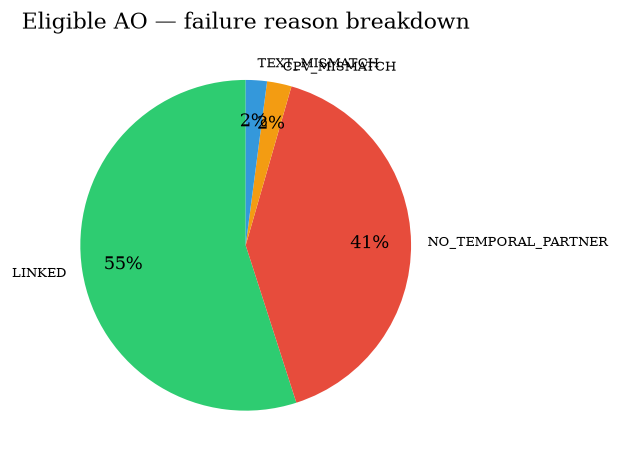

In [36]:
src_with_temporal = set(candidates_df["src_idweb"].astype(str)) if len(candidates_df) > 0 else set()
# A CPV_MISMATCH means a VALID CPV existed but scored 0 (different division) for ALL
# candidates. Sources whose CPV is missing are excluded from the composite, so they are
# NOT counted as CPV mismatches — they fall through to the text test.
src_with_cpv_ok = set(
    candidates_df[
        (candidates_df["cpv_match_score"] > 0) | candidates_df["cpv_match_score"].isna()
    ]["src_idweb"].astype(str)
) if len(candidates_df) > 0 else set()
src_with_text_ok  = set(filtered["src_idweb"].astype(str)) if len(filtered) > 0 else set()

def failure_category(idweb_str):
    if idweb_str in linked_src_ids:
        return "LINKED"
    if idweb_str not in src_with_temporal:
        return "NO_TEMPORAL_PARTNER"
    if idweb_str not in src_with_cpv_ok:
        return "CPV_MISMATCH"
    return "TEXT_MISMATCH"

ao_elig["failure_reason"] = ao_elig["idweb"].astype(str).map(failure_category)

print("Failure breakdown (eligible AO):")
fc = ao_elig["failure_reason"].value_counts()
for reason, count in fc.items():
    print(f"  {reason:<25}: {count:>5,}  ({100*count/n_eligible:.1f}%)")

# Pie chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"LINKED": "#2ecc71", "NO_TEMPORAL_PARTNER": "#e74c3c",
          "CPV_MISMATCH": "#f39c12", "TEXT_MISMATCH": "#3498db"}
wedge_colors = [colors.get(k, "#95a5a6") for k in fc.index]
ax.pie(fc.values, labels=fc.index, autopct="%1.0f%%", colors=wedge_colors,
       startangle=90, pctdistance=0.75)
ax.set_title("Eligible AO — failure reason breakdown")
plt.tight_layout()
plt.show()


### 6.2 Matched vs unmatched distributions

We compare key characteristics of linked vs unlinked eligible AO to assess selection bias. If linked contracts are systematically different (e.g. larger, more recent, or concentrated in one CPV), the survival analysis model may not generalize to the full population.

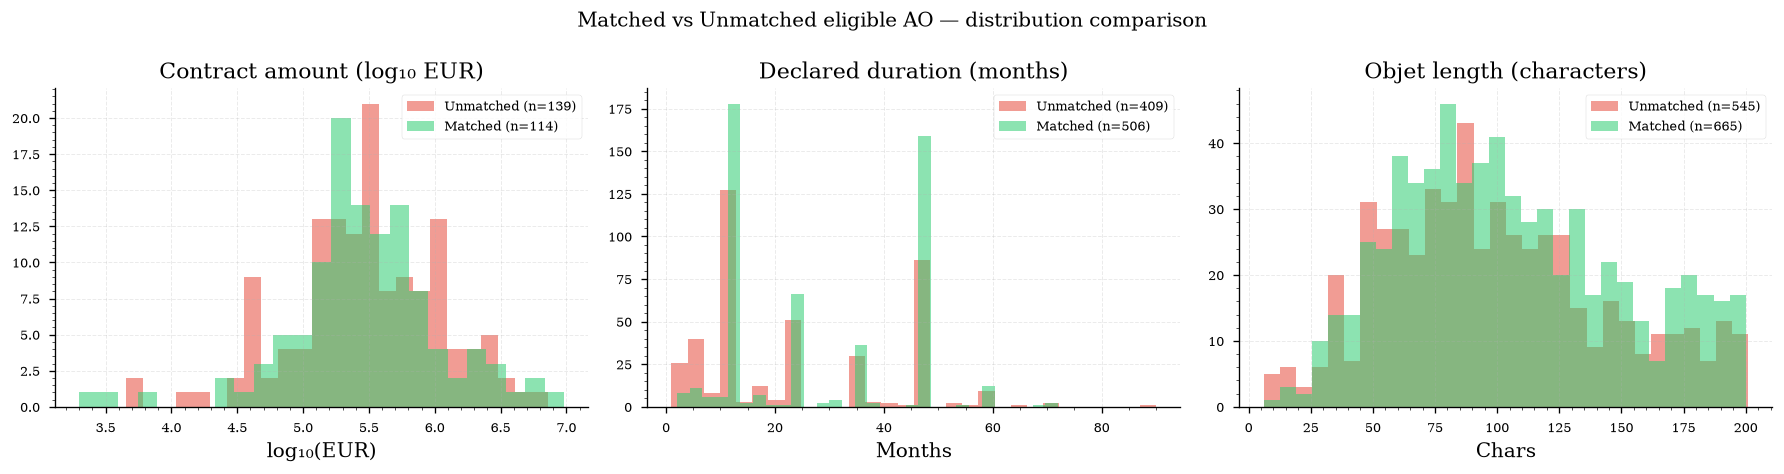


Key statistics — matched vs unmatched:

Matched (n=665):
  amount_clean (median EUR):  282,000
  duration_clean (median m):  24
  objet_len (median chars):   99
  SIRET buyer (%):            0.0%
  imputed duration (%):       23.9%

Unmatched (n=545):
  amount_clean (median EUR):  300,000
  duration_clean (median m):  16
  objet_len (median chars):   92
  SIRET buyer (%):            0.4%
  imputed duration (%):       25.0%


In [37]:
matched   = ao_elig[ao_elig["failure_reason"] == "LINKED"]
unmatched = ao_elig[ao_elig["failure_reason"] != "LINKED"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Amount (log)
ax = axes[0]
m_amt = np.log10(matched["amount_clean"].dropna().pipe(lambda s: s[s > 0]))
u_amt = np.log10(unmatched["amount_clean"].dropna().pipe(lambda s: s[s > 0]))
ax.hist(u_amt, alpha=0.55, bins=25, label=f"Unmatched (n={len(u_amt):,})", color="#e74c3c")
ax.hist(m_amt, alpha=0.55, bins=25, label=f"Matched (n={len(m_amt):,})",   color="#2ecc71")
ax.set(title="Contract amount (log₁₀ EUR)", xlabel="log₁₀(EUR)")
ax.legend(fontsize=8)

# Duration
ax = axes[1]
m_dur = matched["duration_clean"].dropna()
u_dur = unmatched["duration_clean"].dropna()
ax.hist(u_dur, alpha=0.55, bins=30, label=f"Unmatched (n={len(u_dur):,})", color="#e74c3c")
ax.hist(m_dur, alpha=0.55, bins=30, label=f"Matched (n={len(m_dur):,})",   color="#2ecc71")
ax.set(title="Declared duration (months)", xlabel="Months")
ax.legend(fontsize=8)

# Objet length
ax = axes[2]
m_len = matched["objet_len"].dropna()
u_len = unmatched["objet_len"].dropna()
ax.hist(u_len, alpha=0.55, bins=30, label=f"Unmatched (n={len(u_len):,})", color="#e74c3c")
ax.hist(m_len, alpha=0.55, bins=30, label=f"Matched (n={len(m_len):,})",   color="#2ecc71")
ax.set(title="Objet length (characters)", xlabel="Chars")
ax.legend(fontsize=8)

plt.suptitle("Matched vs Unmatched eligible AO — distribution comparison", fontsize=12)
plt.tight_layout()
plt.show()

# Summary stats
print("\nKey statistics — matched vs unmatched:")
for label, subset in [("Matched", matched), ("Unmatched", unmatched)]:
    print(f"\n{label} (n={len(subset):,}):")
    print(f"  amount_clean (median EUR):  {subset['amount_clean'].median():,.0f}")
    print(f"  duration_clean (median m):  {subset['duration_clean'].median():.0f}")
    print(f"  objet_len (median chars):   {subset['objet_len'].median():.0f}")
    print(f"  SIRET buyer (%):            {100*subset['buyer_key'].str.startswith('SIRET:').mean():.1f}%")
    print(f"  imputed duration (%):       {100*subset['dur_was_imputed'].mean():.1f}%")

In [38]:
# Linking rate by CPV division
cpv_rates = (
    ao_elig.groupby("cpv_div2", dropna=False)
    .apply(lambda g: pd.Series({
        "n_eligible": len(g),
        "n_linked": (g["failure_reason"] == "LINKED").sum(),
    }))
    .assign(linking_rate_pct=lambda d: (100 * d["n_linked"] / d["n_eligible"]).round(1))
    .sort_values("n_eligible", ascending=False)
)
print("Linking rate by CPV division (eligible AO):")
print(cpv_rates.to_string())

Linking rate by CPV division (eligible AO):
          n_eligible  n_linked  linking_rate_pct
cpv_div2                                        
72.0             461       283              61.4
48.0             226       142              62.8
32.0             196        98              50.0
35.0              84        37              44.0
45.0              64        23              35.9
NaN               56        23              41.1
30.0              20         7              35.0
39.0              16         9              56.2
79.0              14        10              71.4
50.0              11         5              45.5
64.0              10         4              40.0
44.0               8         3              37.5
18.0               7         4              57.1
71.0               6         1              16.7
37.0               4         3              75.0
38.0               4         2              50.0
31.0               3         2              66.7
90.0               3     

In [39]:
# Buyer-level linking rate (buyers with ≥3 eligible AO)
buyer_stats = (
    ao_elig.groupby("buyer_key", dropna=False)
    .apply(lambda g: pd.Series({
        "n_eligible": len(g),
        "n_linked": (g["failure_reason"] == "LINKED").sum(),
    }))
    .pipe(lambda d: d[d["n_eligible"] >= 3])
    .assign(linking_rate_pct=lambda d: (100 * d["n_linked"] / d["n_eligible"]).round(1))
    .reset_index()
)

print(f"Buyers with ≥3 eligible AO: {len(buyer_stats):,}")
print(f"\nLinking rate distribution (across buyers):")
print(buyer_stats["linking_rate_pct"].describe().round(1))
print(f"\nTop 10 buyers by linking rate:")
print(buyer_stats.sort_values("linking_rate_pct", ascending=False).head(10)[["buyer_key", "n_eligible", "n_linked", "linking_rate_pct"]].to_string(index=False))
print(f"\nBottom 10 buyers by linking rate (≥3 eligible AO):")
print(buyer_stats.sort_values("linking_rate_pct").head(10)[["buyer_key", "n_eligible", "n_linked", "linking_rate_pct"]].to_string(index=False))

Buyers with ≥3 eligible AO: 94

Linking rate distribution (across buyers):
count     94.0
mean      44.5
std       34.8
min        0.0
25%       13.0
50%       40.0
75%       75.0
max      100.0
Name: linking_rate_pct, dtype: float64

Top 10 buyers by linking rate:
            buyer_key  n_eligible  n_linked  linking_rate_pct
NAME:nantes metropole          72        72             100.0
NAME:de loire atlanti           3         3             100.0
      SIREN:225300011          12        12             100.0
      SIREN:234400034          91        91             100.0
      SIREN:200054336           3         3             100.0
      SIREN:214401093          14        14             100.0
      SIREN:244900015          30        30             100.0
      SIREN:264400136          42        41              97.6
      SIREN:214401846          35        34              97.1
         NAME:le mans          22        21              95.5

Bottom 10 buyers by linking rate (≥3 eligible AO):


In [40]:
# Bias report — failure reason × CPV cross-tabulation
bias_report = (
    ao_elig
    .groupby(["failure_reason", "cpv_div2"], dropna=False)
    .agg(
        n=("idweb", "count"),
        pct_with_amount=("amount_clean", lambda x: round(100 * x.notna().mean(), 1)),
        median_duration=("duration_clean", lambda x: round(x.median(), 1)),
        pct_duration_imputed=("dur_was_imputed", lambda x: round(100 * x.mean(), 1)),
        pct_siret_buyer=("buyer_key", lambda x: round(100 * x.str.startswith("SIRET:").mean(), 1)),
        median_objet_len=("objet_len", "median"),
    )
    .reset_index()
)
bias_report.to_csv(OUTPUTS / "boamp_bias_report.csv", index=False)
print(f"Saved bias report → outputs/boamp_bias_report.csv")
print(f"\nPreview:")
bias_report.sort_values(["failure_reason", "n"], ascending=[True, False]).head(12)

Saved bias report → outputs/boamp_bias_report.csv

Preview:


/home/senghakrou/stage-1/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/senghakrou/stage-1/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,failure_reason,cpv_div2,n,pct_with_amount,median_duration,pct_duration_imputed,pct_siret_buyer,median_objet_len
3,CPV_MISMATCH,35.0,6,0.0,9.0,33.3,0.0,108.0
7,CPV_MISMATCH,48.0,6,0.0,48.0,16.7,0.0,34.5
10,CPV_MISMATCH,72.0,5,20.0,5.0,40.0,0.0,109.0
6,CPV_MISMATCH,45.0,3,0.0,18.0,0.0,0.0,149.0
0,CPV_MISMATCH,30.0,1,100.0,12.0,0.0,0.0,88.0
1,CPV_MISMATCH,32.0,1,100.0,66.0,0.0,0.0,7.0
2,CPV_MISMATCH,33.0,1,0.0,NaN,100.0,0.0,129.0
4,CPV_MISMATCH,39.0,1,0.0,10.0,0.0,0.0,34.0
5,CPV_MISMATCH,43.0,1,100.0,4.0,0.0,0.0,85.0
8,CPV_MISMATCH,50.0,1,0.0,12.0,0.0,0.0,180.0


---
## 7. Outputs Inventory

In [41]:
# Verify all outputs were created
expected_outputs = [
    "boamp_renewal_candidates.csv",
    "boamp_renewal_links.csv",
    "boamp_linking_stats.csv",
    "boamp_bias_report.csv",
]

print("=" * 65)
print("OUTPUT FILES")
print("=" * 65)
for fname in expected_outputs:
    fpath = OUTPUTS / fname
    if fpath.exists():
        df_out = pd.read_csv(fpath)
        print(f"\n{fname}")
        print(f"  {len(df_out):,} rows × {len(df_out.columns)} columns")
        print(f"  Columns: {list(df_out.columns)}")
    else:
        print(f"\n{fname}  ← MISSING")
print("=" * 65)

OUTPUT FILES

boamp_renewal_candidates.csv
  3,201 rows × 17 columns
  Columns: ['src_idweb', 'src_buyer_key', 'src_cpv', 'src_contract_start', 'src_duration_months', 'src_objet', 'cand_idweb', 'cand_contract_start', 'cand_cpv', 'cand_objet', 'gap_months', 'buyer_match_score', 'cpv_match_score', 'cpv_used_in_score', 'text_similarity_score', 'temporal_proximity_score', 'composite_score']

boamp_renewal_links.csv
  1,210 rows × 30 columns
  Columns: ['contract_id', 'buyer_key', 'cpv_div2', 'category_label', 'contract_start', 'declared_duration_months', 'dur_was_imputed', 'estimated_end_date', 'event', 'renewal_contract_id', 'observed_duration_months', 'composite_score', 'text_similarity', 'cpv_match_score', 'cpv_used_in_score', 'temporal_score', 'start_date_source', 'link_method', 'type_procedure', 'type_marche', 'flag_amount_zero', 'flag_amount_tiny', 'flag_amount_ceiling', 'amount_clean', 'best_composite_score', 'second_best_composite_score', 'score_margin', 'n_candidates_for_source', 

In [42]:
# Verification assertions
assert len(ao) == n_total_ao,                                    f"Expected {n_total_ao} AO"
assert tfidf_matrix.shape[0] == len(ao),                         "TF-IDF matrix row count mismatch"
assert st_embeddings.shape[0] == len(ao),                        "ST embeddings row count mismatch"
assert st_embeddings.shape[1] == 384,                            "ST embedding dimension should be 384"
assert links_df["event"].isin([0, 1]).all(),                      "event column must be 0/1"
assert len(links_df) == n_eligible,                               "links_df must have one row per eligible AO"
assert all((OUTPUTS / f).exists() for f in expected_outputs),    "Some output files are missing"
print("All assertions passed.")

All assertions passed.


---
## Summary

### What this notebook does

1. Diagnoses 9 data quality issues in the BOAMP dataset relevant to renewal linking
2. Refines contract start dates using award dates from linked ATTRIBUTION notices
3. Builds a **Sentence-Transformers** semantic similarity model (`paraphrase-multilingual-MiniLM-L12-v2`) calibrated on 728 same-contract ground-truth pairs from `annonce_lie` (98.2% score ≥ 0.20)
4. Generates renewal candidate pairs by buyer group, scoring each on 4 interpretable components
5. Filters candidates (text ≥ 0.20, gap in [6, 72] months) and selects the best link per source AO
6. Reports the linking rate with two denominators (eligible and total)
7. Assesses bias between matched and unmatched contracts

### Key algorithmic improvements over the baseline (7.6% at W=6; 11.3% at the earlier W=12 setting)

| Improvement | Impact |
|---|---|
| Group by `buyer_key` only (not `buyer_key + cpv_div2`) | Recovers renewals where CPV drifted between contracts |
| **Sentence-Transformers cosine** instead of TF-IDF / Jaccard | Captures semantic meaning — main driver of improvement (+30 pp vs the TF-IDF intermediate, which was measured on the earlier W=12 eligible pool) |
| Temporal window set to ±6m | Aligns with DECP linking; tighter precision reduces false positives |
| CPV removed from hard filters (kept as scored component) | Recovers cross-CPV renewals from same buyer |

### Results

| Method | Linked | Eligible | Rate |
|---|---|---|---|
| Baseline (Jaccard, buyer+CPV group, W=6) | 146 | 1,933 | 7.6% |
| TF-IDF cosine (intermediate, W=12 pool) | 279 | 1,100 | 25.4% |
| **Sentence-Transformers (final, W=6)** | **665** | **1,210** | **55.0%** |

### Assumptions

| Assumption | Value | Justification |
|---|---|---|
| Default duration when missing | 48 months | Consistent with median of filled durations and prior work |
| Temporal search window | ±6 months | Tighter precision window; aligns with DECP linking approach |
| Text similarity threshold | 0.20 | Calibration: 98.2% of same-contract pairs score ≥ 0.20 with Sentence-Transformers |
| Declared duration meaning | Administrative maximum | Base period + all optional renewals; actual renewal may come earlier |
| `annonce_lie` semantics | Same-contract back-reference | Confirmed from BOAMP documentation and empirical gap distribution |

### Structural ceiling

The main remaining bottleneck is **NO_TEMPORAL_PARTNER**: buyers who issued only one eligible AO notice within the ±6-month window cannot be linked regardless of algorithm quality. The residual unlinked AO are primarily structural. To push further, one would need to:
- Enrich buyer identifiers via SIRENE API (unify fragmented name-based groups)
- Extend the study period beyond 2024

### Limitations and uncertainties

1. **Name-based buyer keys**: after SIREN enrichment, 484 of the 1,210 eligible contracts (40.0%) still rely on a name-normalised buyer key. Variant spellings for the same entity may remain in separate groups, creating structural misses.

2. **Early renewals**: if a buyer renews before the expected end of the base period, the temporal window may miss it — a fundamental limitation of using declared duration as a proxy.

3. **One-to-one matching**: we assign at most one renewal to each source AO. Lot-splitting means a buyer may re-tender the same service across multiple separate notices.

4. **CPV removed from hard filters**: increases recall but may introduce false positives where two unrelated contracts from the same buyer share similar objet text and fall in the right time window.

5. **Model download**: `paraphrase-multilingual-MiniLM-L12-v2` (~120 MB) is downloaded on first run and cached in `~/.cache/huggingface/`. Subsequent runs use the local cache.